# Data Exploration 



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np

In [2]:
# read log data 
logs = pd.read_excel('ICT001 S1 2025 Logs RELEASED V1.0.xlsx')


In [3]:
logs.head()

,Time,User full name,Username,Affected user,Event context,Component,Event name,Description,Origin,IP Address
0,"13/11/25, 09:55:28",John Surname046,20220829@murdoch.edu.au,-,"Unit: ICT001 Theory of Programming (S1, 2025)",System,Unit viewed,The user with id '211844' viewed the course wi...,web,NaN
1,"20/09/25, 19:30:02",John Surname111,15925111@student.murdoch.edu.au,-,"Unit: ICT001 Theory of Programming (S1, 2025)",System,Unit viewed,The user with id '251248' viewed the course wi...,web,NaN
2,"20/09/25, 19:29:35",John Surname111,15925111@student.murdoch.edu.au,-,File: Lab description (PDF),File,Unit module viewed,The user with id '251248' viewed the 'resource...,web,NaN
3,"20/09/25, 19:29:08",John Surname111,15925111@student.murdoch.edu.au,-,File: Solutions (Hidden from Students),File,Unit module viewed,The user with id '251248' viewed the 'resource...,web,NaN
4,"20/09/25, 19:29:04",John Surname111,15925111@student.murdoch.edu.au,-,"Unit: ICT001 Theory of Programming (S1, 2025)",System,Unit viewed,The user with id '251248' viewed the course wi...,web,NaN


In [4]:
# read result data 
results = pd.read_excel('ICT001_S1_2025_RESULTS_ALL_MARKS_RELEASED_v1.0[6076970].xlsx')

In [5]:
results.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 15,Penalty per day,Weight,Unnamed: 18,Penalty per day.1,Weight.1,Weight.2,Weight.3,Unnamed: 23,Unnamed: 24
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,10,10,NaN,10,20,50,100,NaN,NaN
1,Person Id,Surname,Mark,Grade,Ass Ex 1,Ass Ex 2,Ass Ex 3,Ass Ex 4,Ass Ex 5,Ass Ex 6,...,Assignment 1 / 100,Delay (days),Ass 1 with Penalty /100,Ass 2 /100,Delay (days),Ass 2 with Penalty /100,Exam/ 100,Total/ 100,Rounded Total/ 100,Cal G
2,15925001,Surname001,52,P,NaN,40,30,95,50,100,...,76,NaN,76,52.85,NaN,52.85,43,52.17,52,P
3,15925002,Surname002,38,N,85,100,95,100,100,100,...,37,NaN,37,50.35,NaN,50.35,14.5,37.82,38,N
4,15925003,Surname003,2,N,NaN,NaN,25,25,0,20,...,3,NaN,3,NaN,NaN,0,0,1.7,2,N


In [6]:
# compare fields data_log.columns vs mdl_log.columns

mdl_log = pd.read_csv('mdl_logstore_standard_log.csv')
print("Data Log Columns:")
print(logs.columns)
print("\nMDL Log Columns:")
print(mdl_log.columns) 

Data Log Columns:
Index(['Time', 'User full name', 'Username', 'Affected user', 'Event context',
       'Component', 'Event name', 'Description', 'Origin', 'IP Address'],
      dtype='object')

MDL Log Columns:
Index(['id', 'eventname', 'component', 'action', 'target', 'objecttable',
       'objectid', 'crud', 'edulevel', 'contextid', 'contextlevel',
       'contextinstanceid', 'userid', 'courseid', 'relateduserid', 'anonymous',
       'other', 'timecreated', 'origin', 'ip', 'realuserid'],
      dtype='object')


In [7]:
# count how many times each user appears in logs
if 'User ID' in logs.columns:
    user_counts = logs['User ID'].value_counts()
elif 'Username' in logs.columns:
    user_counts = logs['Username'].value_counts()
elif 'User full name' in logs.columns:
    user_counts = logs['User full name'].value_counts()
else:
    user_ids = logs['Description'].str.extract(r"id '(\d+)'", expand=False)
    user_counts = user_ids.value_counts()
print(user_counts)  

Username
15925004@student.murdoch.edu.au    1294
15925153@student.murdoch.edu.au    1223
15925019@student.murdoch.edu.au    1206
15925125@student.murdoch.edu.au    1203
20220829@murdoch.edu.au            1087
                                   ... 
15925058@student.murdoch.edu.au      12
15925024@student.murdoch.edu.au       8
15925164@student.murdoch.edu.au       7
15925170@student.murdoch.edu.au       7
15925041@student.murdoch.edu.au       2
Name: count, Length: 169, dtype: int64


In [8]:
# average number of log entries per user
average_logs_per_user = user_counts.mean()
print(f"Average number of log entries per user: {average_logs_per_user:.2f}")

Average number of log entries per user: 324.33


In [9]:
# check what term/trimester or semester the logs are from event context column
if 'Event context' in logs.columns:
    temp = logs['Event context'].str.extract(
        r'(?i)\b(S1|S2|T1|T2|Trimester\s*1|Trimester\s*2|Semester\s*1|Semester\s*2)\b',
        expand=False
    )
    print(temp.value_counts())
    print("\n")

# check which year of term
if 'Event context' in logs.columns:
    year_temp = logs['Event context'].str.extract(r'(\d{4})', expand=False)
    print(year_temp.value_counts())
    print("\n")


# check if all years are for S1
if 'Event context' in logs.columns:
    s1_years = logs[logs['Event context'].str.contains(r'(?i)\bS1\b')]['Event context'].str.extract(r'(\d{4})', expand=False)
    print(s1_years.value_counts())

Event context
S1    25231
Name: count, dtype: int64


Event context
2025    25231
2024      157
2023       71
2022       64
Name: count, dtype: int64


Event context
2025    25231
Name: count, dtype: int64


In [10]:
# check the source of 2022-24
logs[
    logs['Event context'].str.contains('2024', na=False)
]['Event context'].drop_duplicates()

logs[
    logs['Event context'].str.contains('2023', na=False)
]['Event context'].drop_duplicates()

logs[
    logs['Event context'].str.contains('2022', na=False)
]['Event context'].drop_duplicates()

1621    File: Recorded Session (2022/06/14)
1622    File: Recorded Session (2022/06/07)
Name: Event context, dtype: object

In [11]:
# check the source of 2022-24
if 'Event context' in logs.columns:
    source_2022_24 = logs[
    logs['Event context'].str.contains(
        r'(?i)\b(?:2022|2023|2024)\b',
        na=False
    )
]['Event context'].value_counts()
    print(source_2022_24)

Event context
File: Drop-in Session (Tue 2024/06/04)    157
File: Recorded Session June 12, 2023       71
File: Recorded Session (2022/06/14)        32
File: Recorded Session (2022/06/07)        32
Name: count, dtype: int64


In [12]:
# count least active student log
if 'User ID' in logs.columns:
    least_active_user = user_counts.idxmin()
    least_active_count = user_counts.min()
elif 'Username' in logs.columns:
    least_active_user = user_counts.idxmin()
    least_active_count = user_counts.min()
elif 'User full name' in logs.columns:
    least_active_user = user_counts.idxmin()
    least_active_count = user_counts.min()
else:
    least_active_user = user_counts.idxmin()
    least_active_count = user_counts.min()  
print(f"Least active user: {least_active_user} with {least_active_count} log entries")

Least active user: 15925041@student.murdoch.edu.au with 2 log entries


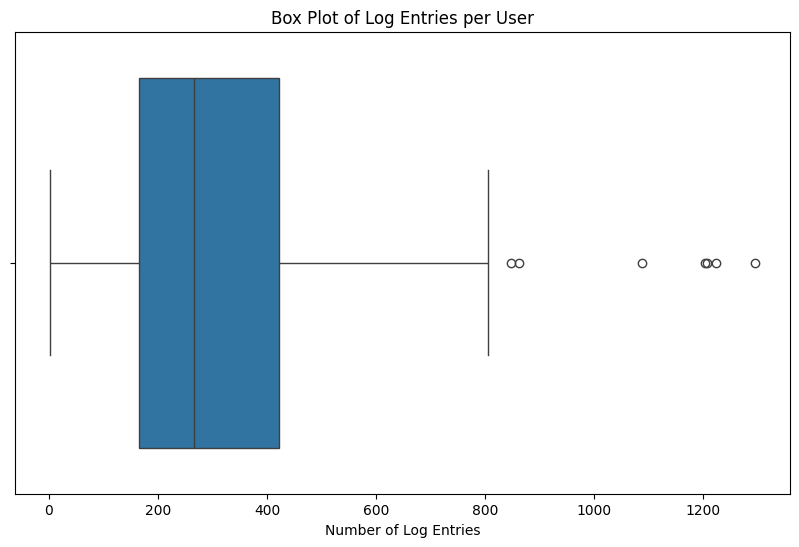

In [13]:
# plot user counts in a box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=user_counts)
plt.title('Box Plot of Log Entries per User')
plt.xlabel('Number of Log Entries')
plt.show()

## Finding 1: Student Engagement Level 
- The moodle activity log analysis revealed variation in student engagment level throughout S1 2025 semester. 
- A total of 169 students, with an average of approx **424 log entries per student**.  
- the box plot shows that most students recorded between approx 170 and 430 log entries, with a media around 270 log and mean 324.33 per student 
- Some students with high activity levels appearing as outliers beyond upper whisker. 
- the most active students recorded more than 1,000 log entries up to over 1,200, while the least active students recorded 2. 

>>These finding indicate that student engagement is highly uneven across sememster. 

Key Statistics

* Total students: 169
* Average log entries per student: 324.33
* Highest activity: 1,294 log entries
* Lowest activity: 2 log entries
* Several high-activity outliers (> 800 log entries) were identified


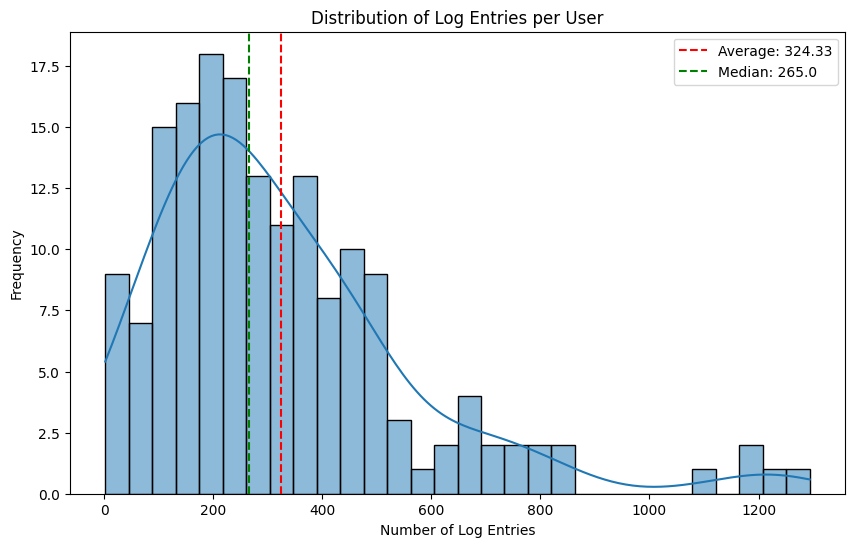

In [14]:
# distribution of log entries per user with average line and median line
plt.figure(figsize=(10, 6))
sns.histplot(user_counts, bins=30, kde=True)        
plt.axvline(average_logs_per_user, color='red', linestyle='--', label=f'Average: {average_logs_per_user:.2f}')
plt.axvline(user_counts.median(), color='green', linestyle='--', label=f'Median: {user_counts.median()}')
plt.title('Distribution of Log Entries per User')
plt.xlabel('Number of Log Entries')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [15]:
print(user_counts.describe())

count     169.000000
mean      324.331361
std       243.548878
min         2.000000
25%       165.000000
50%       265.000000
75%       421.000000
max      1294.000000
Name: count, dtype: float64


## Finding 2: Student Activity Distribution is Right-Skewed 

The distribution of Moodle log entries per student is right-skewed, indicating that most students generated a moderate number of LMS interactions, while a small number of students are exceptionally active. 

Key observations: 
 * The average number of log entries per student was 324.33
 * Most students recorded between approx 150 and 500 log entries. 
 * the highest concentration of students appears around 200-300 log entries, suggesting this represents the typical engagement level within the term. 
 * A small number of students generated more activity, with several students exceeding 1,000 log entries. 
 * The most active student recorded 1,294 log entries, while the least active students recorded only 2 log entries. 

 The long tail on the right side of the distribution indicates the presence of highly active students who accessed Moodle resources considerably more frequently than the rest of the cohort. These extreme values contribute to the righ-skewed shape and increase the overall average. 

 Interpretation 
 The distribution suggests that student engagement is not evenly distributed across the cohort. While most students demostrated moderated LMS usage, a subset of students exhibit either: 
 * **very highly engagement**, potentially due to frequent access to learning materials, repeated review of resources, or intensive study behavior; or 
 * **Very low engagemen**, which may indicate disengagment and could serve as an early warning sigh for academic risk. 

 

## Relationship between log entries and student results 


In [16]:
results = pd.read_excel(
    "ICT001_S1_2025_RESULTS_ALL_MARKS_RELEASED_v1.0[6076970].xlsx",
    header=2
)

results.head()

,Person Id,Surname,Mark,Grade,Ass Ex 1,Ass Ex 2,Ass Ex 3,Ass Ex 4,Ass Ex 5,Ass Ex 6,...,Assignment 1 / 100,Delay (days),Ass 1 with Penalty /100,Ass 2 /100,Delay (days).1,Ass 2 with Penalty /100,Exam/ 100,Total/ 100,Rounded Total/ 100,Cal G
0,15925001.0,Surname001,52.0,P,NaN,40.0,30.0,95.0,50.0,100.0,...,76,NaN,76.0,52.85,NaN,52.85,43.00,52.17,52,P
1,15925002.0,Surname002,38.0,N,85.0,100.0,95.0,100.0,100.0,100.0,...,37,NaN,37.0,50.35,NaN,50.35,14.50,37.82,38,N
2,15925003.0,Surname003,2.0,N,NaN,NaN,25.0,25.0,0.0,20.0,...,3,NaN,3.0,NaN,NaN,0.00,0.00,1.7,2,N
3,15925004.0,Surname004,46.0,S,60.0,40.0,45.0,35.0,75.0,55.0,...,31,NaN,31.0,68.00,NaN,68.00,36.25,45.825,46,S
4,15925005.0,Surname005,45.0,S,100.0,100.0,100.0,95.0,100.0,NaN,...,69,NaN,69.0,63.30,NaN,63.30,21.00,44.56,45,S


In [17]:
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Person Id                 170 non-null    float64
 1   Surname                   170 non-null    object 
 2   Mark                      167 non-null    float64
 3   Grade                     170 non-null    object 
 4   Ass Ex 1                  149 non-null    float64
 5   Ass Ex 2                  152 non-null    float64
 6   Ass Ex 3                  137 non-null    float64
 7   Ass Ex 4                  129 non-null    float64
 8   Ass Ex 5                  127 non-null    float64
 9   Ass Ex 6                  125 non-null    float64
 10  Ass Ex 7                  118 non-null    float64
 11  Ass Ex 8                  114 non-null    float64
 12  Ass Ex 9                  103 non-null    float64
 13  Ass Ex 10                 105 non-null    float64
 14  Weekly Lab

In [18]:
results.describe()

,Person Id,Mark,Ass Ex 1,Ass Ex 2,Ass Ex 3,Ass Ex 4,Ass Ex 5,Ass Ex 6,Ass Ex 7,Ass Ex 8,Ass Ex 9,Ass Ex 10,Weekly Lab Quizzes / 100,Delay (days),Ass 1 with Penalty /100,Ass 2 /100,Delay (days).1,Ass 2 with Penalty /100,Exam/ 100
count,1.700000e+02,167.000000,149.000000,152.000000,137.000000,129.000000,127.000000,125.000000,118.000000,114.000000,103.000000,105.000000,170.000000,0.0,171.000000,146.000000,0.0,171.000000,144.000000
mean,1.592509e+07,41.191617,75.704698,69.243421,72.583942,75.054264,71.440945,76.360000,76.059322,73.771930,74.854369,67.619048,54.261176,NaN,57.959064,61.635000,NaN,52.025497,33.611111
std,4.921890e+01,24.123661,27.026139,29.039593,30.084597,27.991994,30.196881,26.238484,22.803993,24.418561,26.655540,36.149365,30.714848,NaN,30.014233,25.783175,NaN,32.336035,25.852675
min,1.592500e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000
25%,1.592504e+07,23.000000,60.000000,50.000000,55.000000,65.000000,50.000000,60.000000,65.000000,61.250000,60.000000,45.000000,29.125000,NaN,42.000000,50.087500,NaN,25.950000,9.750000
50%,1.592509e+07,44.000000,85.000000,70.000000,85.000000,85.000000,80.000000,90.000000,77.500000,77.500000,85.000000,85.000000,61.750000,NaN,64.000000,65.650000,NaN,62.000000,31.375000
75%,1.592513e+07,60.000000,100.000000,95.000000,100.000000,95.000000,99.500000,100.000000,98.750000,95.000000,100.000000,100.000000,82.375000,NaN,82.750000,81.325000,NaN,78.115000,54.000000
max,1.592517e+07,86.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,NaN,100.000000,100.000000,NaN,97.900000,100.000000


In [19]:
results.Grade.value_counts()

Grade
N     73
P     23
C     19
D     16
S     14
SA    13
HD     9
DX     3
Name: count, dtype: int64

In [20]:
# how many % of students got each grade
grade_counts = results['Grade'].value_counts(normalize=True) * 100
print(grade_counts)

Grade
N     42.941176
P     13.529412
C     11.176471
D      9.411765
S      8.235294
SA     7.647059
HD     5.294118
DX     1.764706
Name: proportion, dtype: float64


In [21]:
# Clean Person Id in logs
if 'Username' in logs.columns:
    logs['Person Id'] = (
        logs['Username']
        .astype(str)
        .str.extract(r'(\d+)', expand=False)
        .astype('string')
        .str.strip()
    )
    print(logs[['Username', 'Person Id']].head())
else:
    print("Column 'Username' not found in logs.")

                          Username Person Id
0          20220829@murdoch.edu.au  20220829
1  15925111@student.murdoch.edu.au  15925111
2  15925111@student.murdoch.edu.au  15925111
3  15925111@student.murdoch.edu.au  15925111
4  15925111@student.murdoch.edu.au  15925111


In [22]:
# Clean Person Id in results
if 'Person Id' in results.columns:
    results['Person Id'] = (
        results['Person Id']
        .astype(str)
        .str.extract(r'(\d+)', expand=False)
        .astype('string')
        .str.strip()
    )
    print(results[['Person Id']].head())
else:
    print("Column 'Person Id' not found in results.")

  Person Id
0  15925001
1  15925002
2  15925003
3  15925004
4  15925005


In [23]:
# Aggregate logs first: one row per student
log_entries = (
    logs
    .dropna(subset=['Person Id'])
    .groupby('Person Id')
    .size()
    .reset_index(name='Log Entries')
)

# Merge with results: one row per student
student_level_df = pd.merge(
    results[['Person Id', 'Grade', 'Mark']],
    log_entries,
    on='Person Id',
    how='left'
)

student_level_df['Log Entries'] = (
    student_level_df['Log Entries']
    .fillna(0)
    .astype(int)
)

# Average log entries by grade
student_level_df.groupby('Grade')['Log Entries'].mean()

Grade
C     298.789474
D     460.250000
DX    447.000000
HD    432.000000
N     226.520548
P     367.000000
S     394.214286
SA    381.461538
Name: Log Entries, dtype: float64

In [24]:
print(len(student_level_df))
print(student_level_df['Person Id'].nunique())

236
170


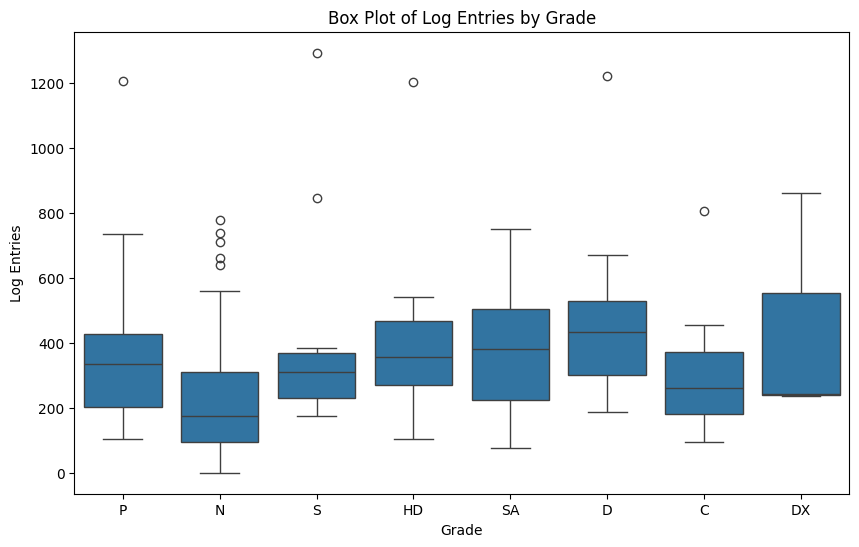

In [25]:
# check corelation between log entries and grades
plt.figure(figsize=(10, 6))
sns.boxplot(x='Grade', y='Log Entries', data=student_level_df)
plt.title('Box Plot of Log Entries by Grade')
plt.xlabel('Grade') 
plt.show()

## Finding 3: Higher Academic Performance is generally associated with greater LMS engagement 
The analysis indicates a positive relationship between LMS activity and academic performance. Students achieving higher grades generally recorded more Moodle interactions than students with lower grades. 

The lowest average activity level was observed among students who received N grade, with approx 227 log entries, while students achieving D and HD averaged more than 430 entries. 

This suggests that students who interact more frequently with Moodle resources tend to achieve better academic outcomes. 

**However, the relationship is not perfectly linear.** Several lower-performing categories, including S and SA, also exhibit relatively high activity levfels. 

*Hypothesis 1: This suggests that activity quantity alone does not fully explain academic performance. Some student may access materials frequently because they are struggling and revisiting resources, while others may achieve strong results through more efficient study behavior. Stuents with more log entries tend to have higher grades, but log entries alone do not strongly explain marks.*


### Implication for the Smart LMS Dashboard
These findings suggest that LMS engagment metrics can serve as useful indicators for identifying at-risk students. Students with persistently low activity levels may warrant early intervention. However, engagement volume alone should not be used as the sole predictor of academic performance; additional behavioral indicators such as 
* assignment submissions
* weekly quizzes participation
* assessment exercises 
* active study weeks
* resource access patterns should also be considered. 

In [26]:
# create a analysis df for correlation between log entries and marks
analysis_df = student_level_df[['Person Id', 'Mark', 'Log Entries']].copy()

analysis_df['Mark'] = pd.to_numeric(analysis_df['Mark'], errors='coerce')
analysis_df['Log Entries'] = pd.to_numeric(analysis_df['Log Entries'], errors='coerce')

analysis_df = analysis_df.dropna(subset=['Mark', 'Log Entries'])

corr = analysis_df[['Mark', 'Log Entries']].corr()
print(corr)

                 Mark  Log Entries
Mark         1.000000     0.408232
Log Entries  0.408232     1.000000


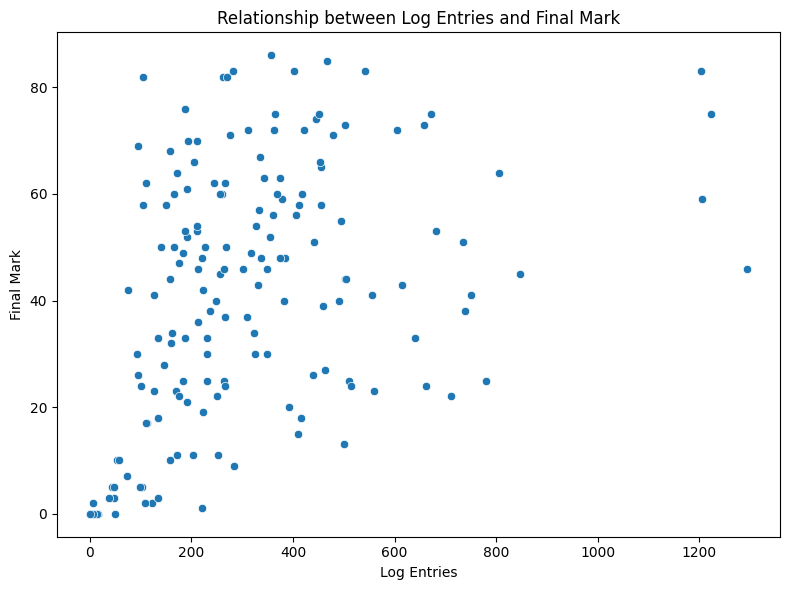

In [27]:
# plot scatter plot of log entries vs marks
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=student_level_df.dropna(subset=['Mark', 'Log Entries']),
    x='Log Entries',
    y='Mark'
)

plt.title('Relationship between Log Entries and Final Mark')
plt.xlabel('Log Entries')
plt.ylabel('Final Mark')
plt.tight_layout()
plt.show()

## Finding 4: Students with more LMS log entries tend to have higher marks, but log entries alone do not strongly explain marks

A moderate positive correlation of 0.408 was found between LMS log entries and final marks. This support the **Hypothesis 1**. the relationship is not strong enough to rely on log count alone for prediction, supporting the need to include additional indicators it mentioned. 

/var/folders/nc/364srb_x0m926dqwk2stdknw0000gn/T/ipykernel_38166/3989654381.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  compare_logs['Time'] = pd.to_datetime(compare_logs['Time'], errors='coerce', dayfirst=True)


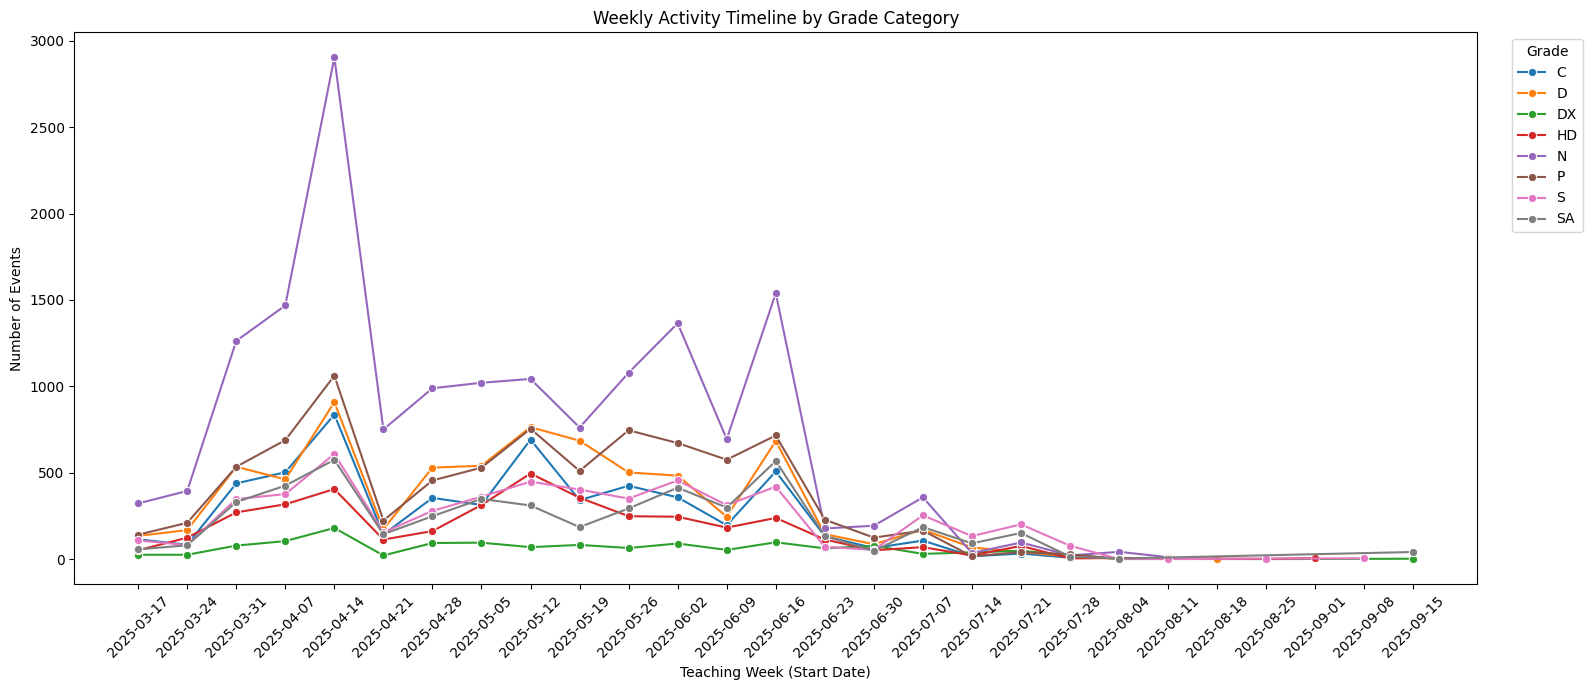

In [28]:
# compare weekly activity timeline for all grade categories (SA, P, D, HD, N, DX, etc.)
compare_students = student_level_df[['Person Id', 'Grade']].drop_duplicates().copy()
compare_students = compare_students.dropna(subset=['Grade'])
compare_students['Grade'] = compare_students['Grade'].astype(str).str.strip()

compare_logs = pd.merge(
    logs.copy(),
    compare_students,
    on='Person Id',
    how='inner'
)

compare_logs['Time'] = pd.to_datetime(compare_logs['Time'], errors='coerce', dayfirst=True)
compare_logs = compare_logs.dropna(subset=['Time'])

compare_logs['WeekStart'] = compare_logs['Time'].dt.to_period('W').dt.start_time
compare_weekly = (
    compare_logs
    .groupby(['WeekStart', 'Grade'])
    .size()
    .reset_index(name='Count')
 )

compare_weekly['Week'] = compare_weekly['WeekStart'].dt.strftime('%Y-%m-%d')

grade_order = sorted(compare_weekly['Grade'].unique().tolist())
compare_weekly['Grade'] = pd.Categorical(
    compare_weekly['Grade'],
    categories=grade_order,
    ordered=True
 )


plt.figure(figsize=(16, 7))
sns.lineplot(
    data=compare_weekly.sort_values(['WeekStart', 'Grade']),
    x='Week',
    y='Count',
    hue='Grade',
    marker='o'
 )
plt.title('Weekly Activity Timeline by Grade Category')
plt.xlabel('Teaching Week (Start Date)')
plt.ylabel('Number of Events')
plt.xticks(rotation=45)
plt.legend(title='Grade', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

*Figure 2:*

/var/folders/nc/364srb_x0m926dqwk2stdknw0000gn/T/ipykernel_38166/1637682109.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  compare_logs['Time'] = pd.to_datetime(compare_logs['Time'], errors='coerce', dayfirst=True)


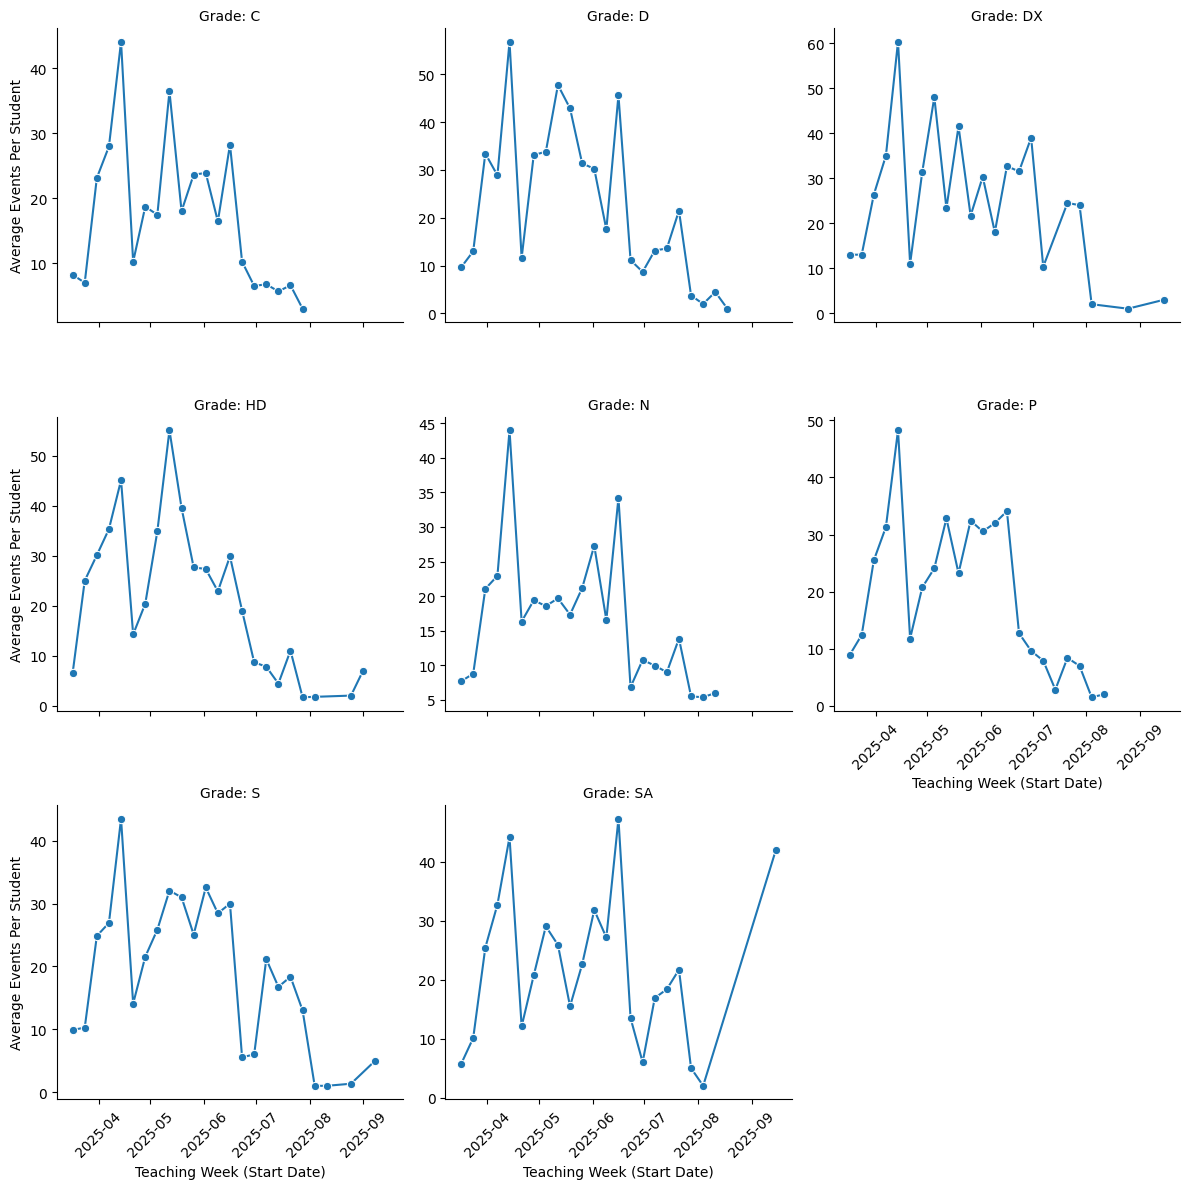

In [29]:
# compare weekly activity timeline for all grade categories (SA, P, D, HD, N, DX, etc.)
compare_students = student_level_df[['Person Id', 'Grade']].drop_duplicates().copy()
compare_students = compare_students.dropna(subset=['Grade'])
compare_students['Grade'] = compare_students['Grade'].astype(str).str.strip()

compare_logs = pd.merge(
    logs.copy(),
    compare_students,
    on='Person Id',
    how='inner'
)

compare_logs['Time'] = pd.to_datetime(compare_logs['Time'], errors='coerce', dayfirst=True)
compare_logs = compare_logs.dropna(subset=['Time'])

compare_logs['WeekStart'] = compare_logs['Time'].dt.to_period('W').dt.start_time
compare_weekly = (
    compare_logs
    .groupby(['WeekStart', 'Grade'])
    .size()
    .reset_index(name='Count')
 )

compare_weekly['Week'] = compare_weekly['WeekStart'].dt.strftime('%Y-%m-%d')

grade_order = sorted(compare_weekly['Grade'].unique().tolist())
compare_weekly['Grade'] = pd.Categorical(
    compare_weekly['Grade'],
    categories=grade_order,
    ordered=True
 )

# normalize by student count
weekly_student_activity = (
    compare_logs
    .groupby(['WeekStart', 'Grade', 'Person Id'])
    .size()
    .reset_index(name='Events')
)

weekly_avg = (
    weekly_student_activity
    .groupby(['WeekStart', 'Grade'])['Events']
    .mean()
    .reset_index()
)


import plotly.express as px

fig = px.line(
    weekly_avg,
    x='WeekStart',
    y='Events',
    color='Grade',
    markers=True,
    hover_data={'WeekStart': True, 'Events': True, 'Grade': True}
)

fig.update_layout(
    title='Average Weekly Events Per Student by Grade',
    xaxis_title='Teaching Week (Start Date)',
    yaxis_title='Average Events Per Student',
    legend_title='Grade'
)

fig.show()

# plot for multiple grade categories in multiple plots add tooltips 
g = sns.FacetGrid(
    weekly_avg,
    col='Grade',
    col_wrap=3,
    height=4,
    sharey=False
)
g.map(sns.lineplot, 'WeekStart', 'Events', marker='o')  
g.set_titles(col_template='Grade: {col_name}')
g.set_axis_labels('Teaching Week (Start Date)', 'Average Events Per Student')
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Finding 6: Average Weekly Events Per Student by Grade (Raw Event Counts Vs Normalized counts)

### Raw Event Counts

The figure 2 shows the total number of Moodle events generated each week for students in different grade categories. Across all grades, activity generally increased from March to June, peaked during major teaching and assessment periods, and declined sharply after later June. 

the N category consistenly generately the highest number of events, reaching almost 2,900 events during the week begining 14th April 2025. Other grade categories followed similar temporal patterns, with noticeable activity peaks around assessment periods. 

### Interpretation 
At first glance, the chart may suggest that students who received an N grade were the most active users of the LMS. However, this interpretation would be misleading because the grade categories contain different numbers of students. 

Dataset contains 42% of N grades than the other groups, it naturally generates more Moodle events overall. Therefore, the chart primarily reflects cohort size differences rather than individual student behavior. 

The chart is useful for understanding overall activity trends and identifying key periods of LMS usage throughout the semester. However, it is not suitable for comparing engagement behavior across grade categories becasue student population sizes vary consistenly. 


## Normalized Counts 

To remove the effect of equal cohort sizes, weekly counts were normalized by the number of students in each grade category. The resulting chart shows the average number of Moodle events generated per student each week. 

After normalization, the large differences observed in the previous chart become substantially smaller. Most grade categories follow very similar engagement pattterns throughout the semester. 

### Interpretation 
The normalized chart reveals that students across different grade categories generally interacted with Moodle at comparable levels. Again, although some variaion exists between grades in certain weeks, there is no clear seperation between high-performing and low-performing students based solely on LMS activity volume. 




In [30]:
logs['Time'].head(10)

0    13/11/25, 09:55:28
1    20/09/25, 19:30:02
2    20/09/25, 19:29:35
3    20/09/25, 19:29:08
4    20/09/25, 19:29:04
5    20/09/25, 19:28:42
6    20/09/25, 19:28:18
7    20/09/25, 19:28:14
8    20/09/25, 19:27:50
9    20/09/25, 19:27:16
Name: Time, dtype: object

In [31]:
# check what type of log entries for SA grade students
sa_students = student_level_df[student_level_df['Grade'] == 'SA']
sa_student_ids = sa_students['Person Id'].tolist()
sa_logs = logs[logs['Person Id'].isin(sa_student_ids)].copy()
print(sa_logs.head()) 

                 Time   User full name                         Username  \
1  20/09/25, 19:30:02  John Surname111  15925111@student.murdoch.edu.au   
2  20/09/25, 19:29:35  John Surname111  15925111@student.murdoch.edu.au   
3  20/09/25, 19:29:08  John Surname111  15925111@student.murdoch.edu.au   
4  20/09/25, 19:29:04  John Surname111  15925111@student.murdoch.edu.au   
5  20/09/25, 19:28:42  John Surname111  15925111@student.murdoch.edu.au   

  Affected user                                  Event context Component  \
1             -  Unit: ICT001 Theory of Programming (S1, 2025)    System   
2             -                    File: Lab description (PDF)      File   
3             -         File: Solutions (Hidden from Students)      File   
4             -  Unit: ICT001 Theory of Programming (S1, 2025)    System   
5             -                    File: Lab description (PDF)      File   

           Event name                                        Description  \
1         Unit v

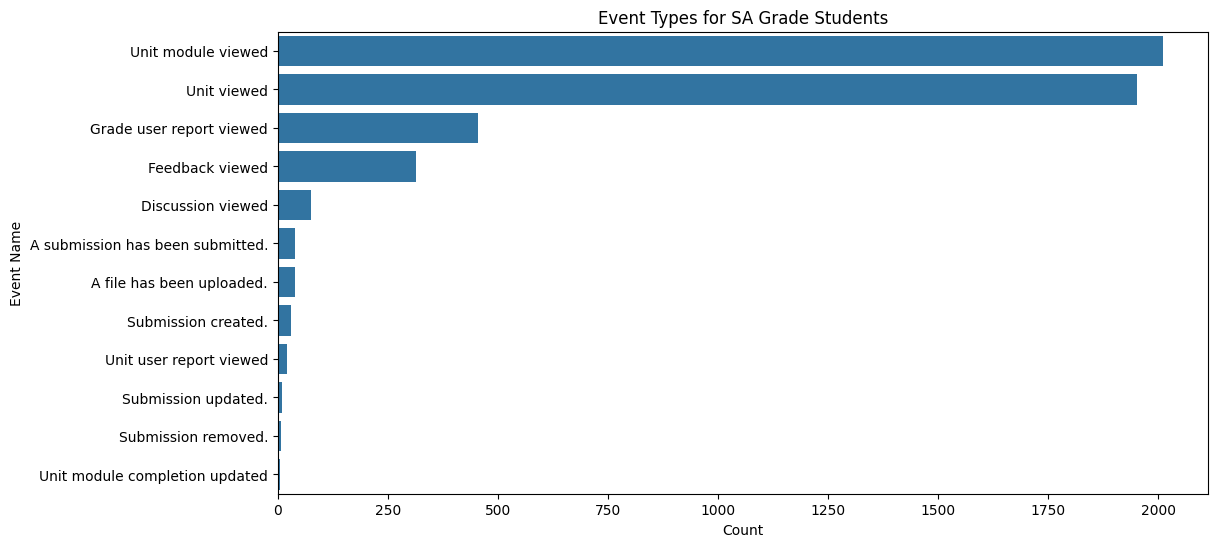

In [32]:
# plot event types for SA grade students
plt.figure(figsize=(12, 6))
sns.countplot(y='Event name', data=sa_logs, order=sa_logs['Event name'].value_counts().index)
plt.title('Event Types for SA Grade Students')
plt.xlabel('Count')
plt.ylabel('Event Name')
plt.show()

In [33]:
# extract material type from log event name
sa_logs['Material Type'] = sa_logs['Event name'].str.extract(r'(?i)\b(?:viewed|accessed|opened|downloaded|submitted|attempted|completed|started|finished|updated|deleted|created|logged in|logged out)\s+(\w+)', expand=False)
print(sa_logs[['Event name', 'Material Type']].head())

           Event name Material Type
1         Unit viewed           NaN
2  Unit module viewed           NaN
3  Unit module viewed           NaN
4         Unit viewed           NaN
5  Unit module viewed           NaN


### Diagnostics 1: Activity timeline by Grade 


In [34]:
# Why S and SA have higher logs entries than P and C? 
data_log = logs.copy()

data_log['Person Id'] = (
    data_log['Username']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
    .astype('string')
)

merged_df = pd.merge(
    results[['Person Id', 'Grade']].dropna(subset=['Person Id', 'Grade']),
    log_entries,
    on='Person Id',
    how='left'
)

merged_df['Person Id'] = (
    merged_df['Person Id']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
)

# Merge raw logs with grade labels
grade_logs = pd.merge(
    data_log.copy(),
    merged_df[['Person Id', 'Grade']].drop_duplicates(),
    on='Person Id',
    how='inner'
)

# Convert Time column
grade_logs['Time'] = pd.to_datetime(
    grade_logs['Time'],
    errors='coerce',
    dayfirst=True
)

grade_logs = grade_logs.dropna(subset=['Time'])



/var/folders/nc/364srb_x0m926dqwk2stdknw0000gn/T/ipykernel_38166/2218714709.py:33: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [35]:
# check term start and end dates for S1 2025
term_dates = grade_logs['Time'].agg(['min', 'max'])
print(f"Term Start Date: {term_dates['min']}")
print(f"Term End Date: {term_dates['max']}")
print("Total days in term:", (term_dates['max'] - term_dates['min']).days)

Term Start Date: 2025-03-21 05:10:29
Term End Date: 2025-09-20 19:30:02
Total days in term: 183


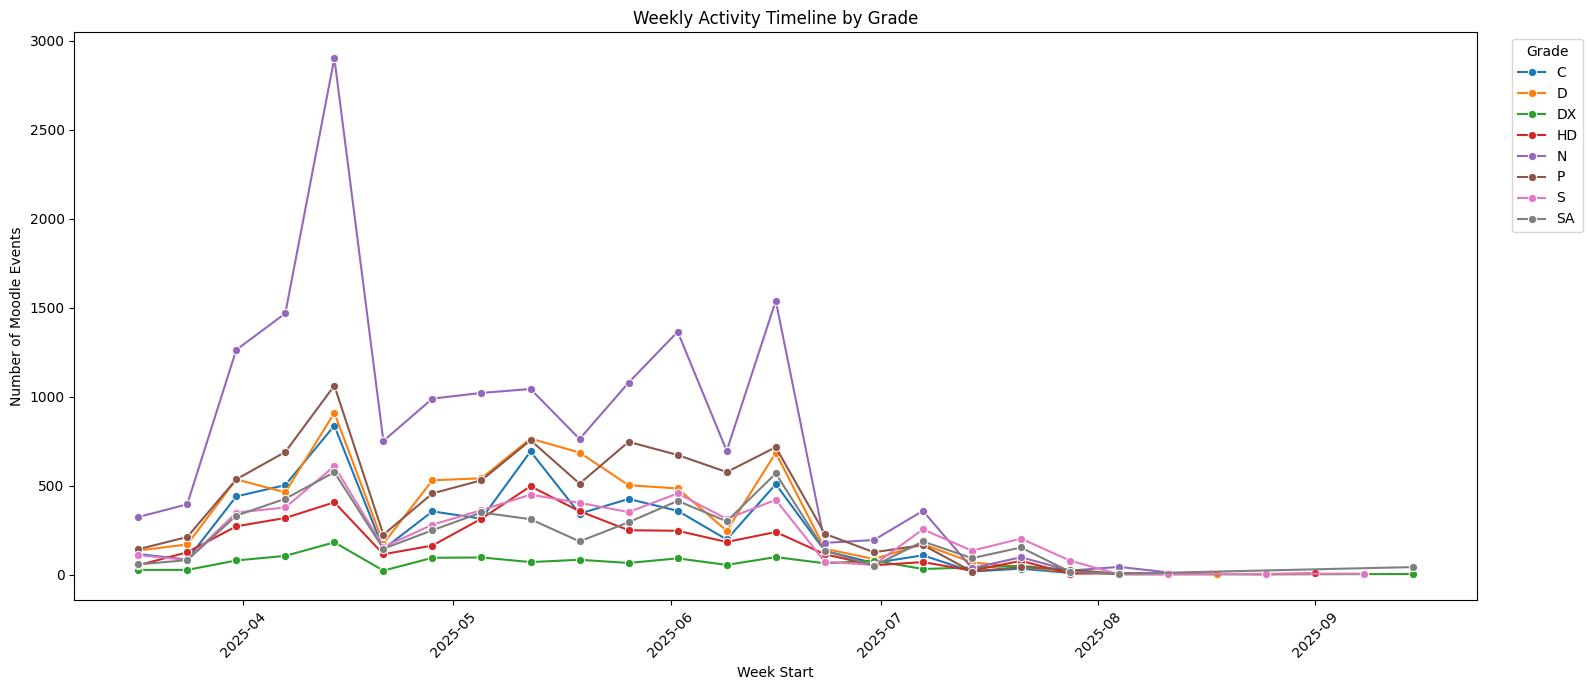

In [36]:
# weekly activity by grade category
grade_logs['WeekStart'] = grade_logs['Time'].dt.to_period('W').dt.start_time
weekly_grade_activity = (
    grade_logs
    .groupby(['WeekStart', 'Grade'])
    .size()
    .reset_index(name='Count')
)   

weekly_grade_activity = (
    grade_logs
    .groupby(['WeekStart', 'Grade'])
    .size()
    .reset_index(name='Event Count')
)

plt.figure(figsize=(16, 7))

sns.lineplot(
    data=weekly_grade_activity,
    x='WeekStart',
    y='Event Count',
    hue='Grade',
    marker='o'
)

plt.title('Weekly Activity Timeline by Grade')
plt.xlabel('Week Start')
plt.ylabel('Number of Moodle Events')
plt.xticks(rotation=45)
plt.legend(title='Grade', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

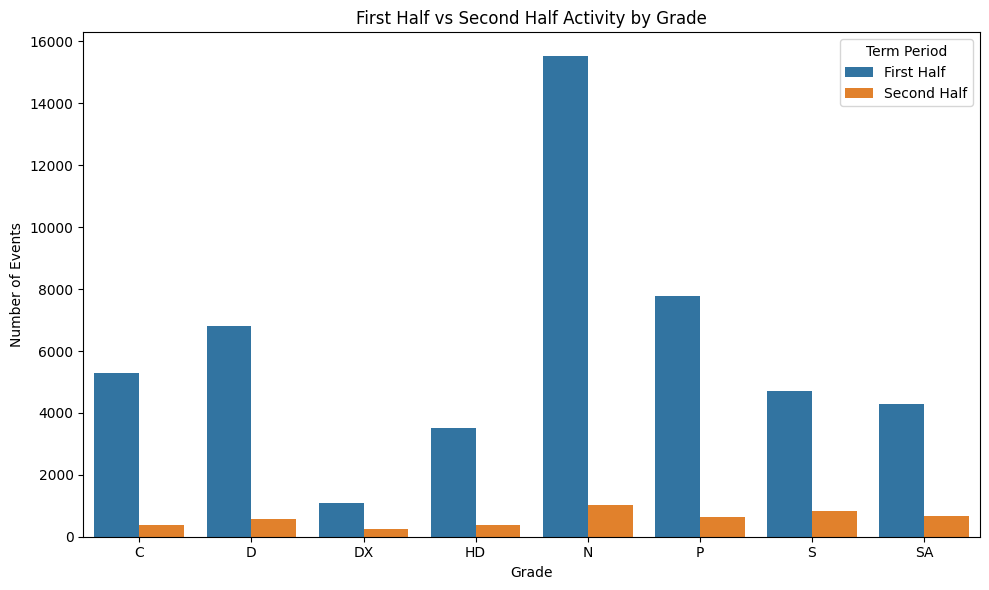

In [37]:
term_start = term_dates['min']
term_end = term_dates['max']
midpoint = term_start + (term_end - term_start) / 2

grade_logs['Term Period'] = np.where(
    grade_logs['Time'] < midpoint,
    'First Half',
    'Second Half'
)

period_activity = (
    grade_logs
    .groupby(['Grade', 'Term Period'])
    .size()
    .reset_index(name='Event Count')
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=period_activity,
    x='Grade',
    y='Event Count',
    hue='Term Period'
)

plt.title('First Half vs Second Half Activity by Grade')
plt.xlabel('Grade')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

In [38]:
# calculate active weeks for each student 
if 'WeekStart' in grade_logs.columns:
    active_weeks = grade_logs.groupby('Person Id')['WeekStart'].nunique()
else:
    active_weeks = (
        grade_logs.assign(
            Time=pd.to_datetime(grade_logs['Time'], errors='coerce', dayfirst=True)
        )
        .dropna(subset=['Time'])
        .groupby('Person Id')['Time']
        .apply(lambda x: x.dt.isocalendar().week.nunique())
    )

active_weeks.describe()

count    168.000000
mean      14.273810
std        4.424621
min        1.000000
25%       12.000000
50%       16.000000
75%       17.000000
max       23.000000
Name: WeekStart, dtype: float64

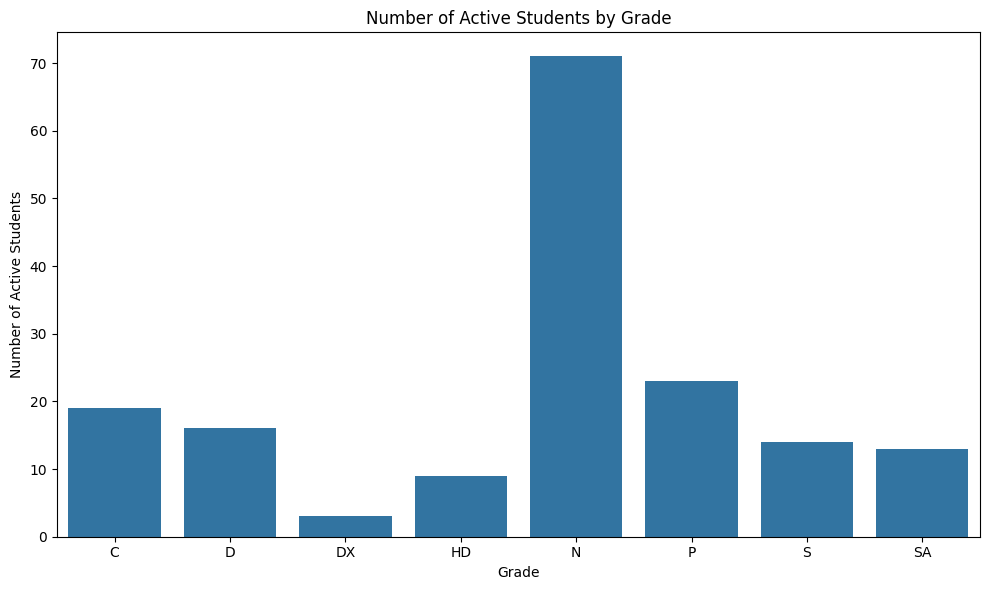

In [39]:
# compare active weeks by grade category
grade_active_weeks = (
    grade_logs.groupby('Grade')['Person Id'].nunique().reset_index(name='Active Students')
)   
plt.figure(figsize=(10, 6))
sns.barplot(
    data=grade_active_weeks,
    x='Grade',
    y='Active Students'
)
plt.title('Number of Active Students by Grade')
plt.xlabel('Grade')
plt.ylabel('Number of Active Students')
plt.tight_layout()
plt.show()

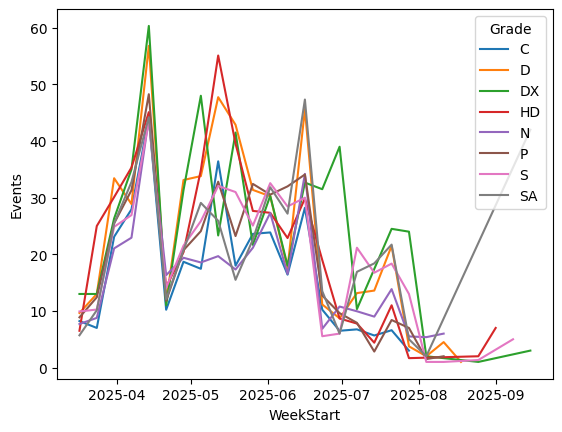

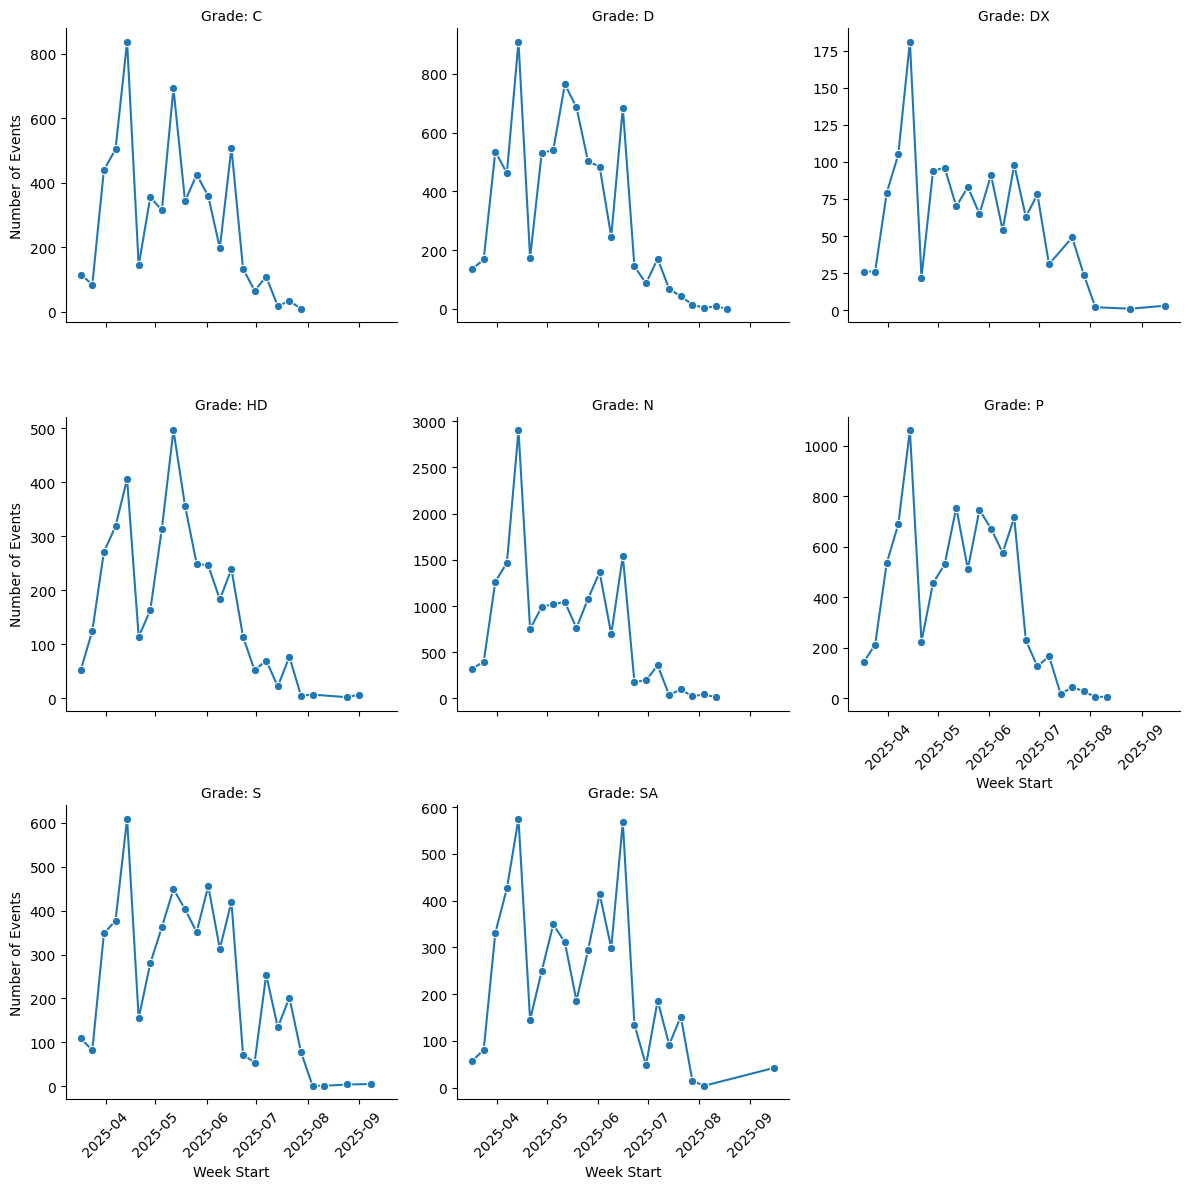

In [40]:
weekly_student_activity = (
    grade_logs
    .groupby(['WeekStart', 'Grade', 'Person Id'])
    .size()
    .reset_index(name='Events')
)

weekly_avg = (
    weekly_student_activity
    .groupby(['WeekStart', 'Grade'])['Events']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=weekly_avg,
    x='WeekStart',
    y='Events',
    hue='Grade'
)

# create small multiples of weekly activity by grade category
g = sns.FacetGrid(weekly_grade_activity, col='Grade', col_wrap=3, height=4, sharey=False)
g.map(sns.lineplot, 'WeekStart', 'Event Count', marker='o')
g.set_titles('Grade: {col_name}')
g.set_axis_labels('Week Start', 'Number of Events')
for ax in g.axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [41]:
student_active_weeks = (
    grade_logs
    .groupby(['Person Id', 'Grade'])['WeekStart']
    .nunique()
    .reset_index(name='Active Weeks')
)

student_active_weeks.groupby('Grade')['Active Weeks'].mean()

Grade
C     14.947368
D     16.687500
DX    16.666667
HD    17.666667
N     11.535211
P     15.739130
S     17.428571
SA    16.384615
Name: Active Weeks, dtype: float64

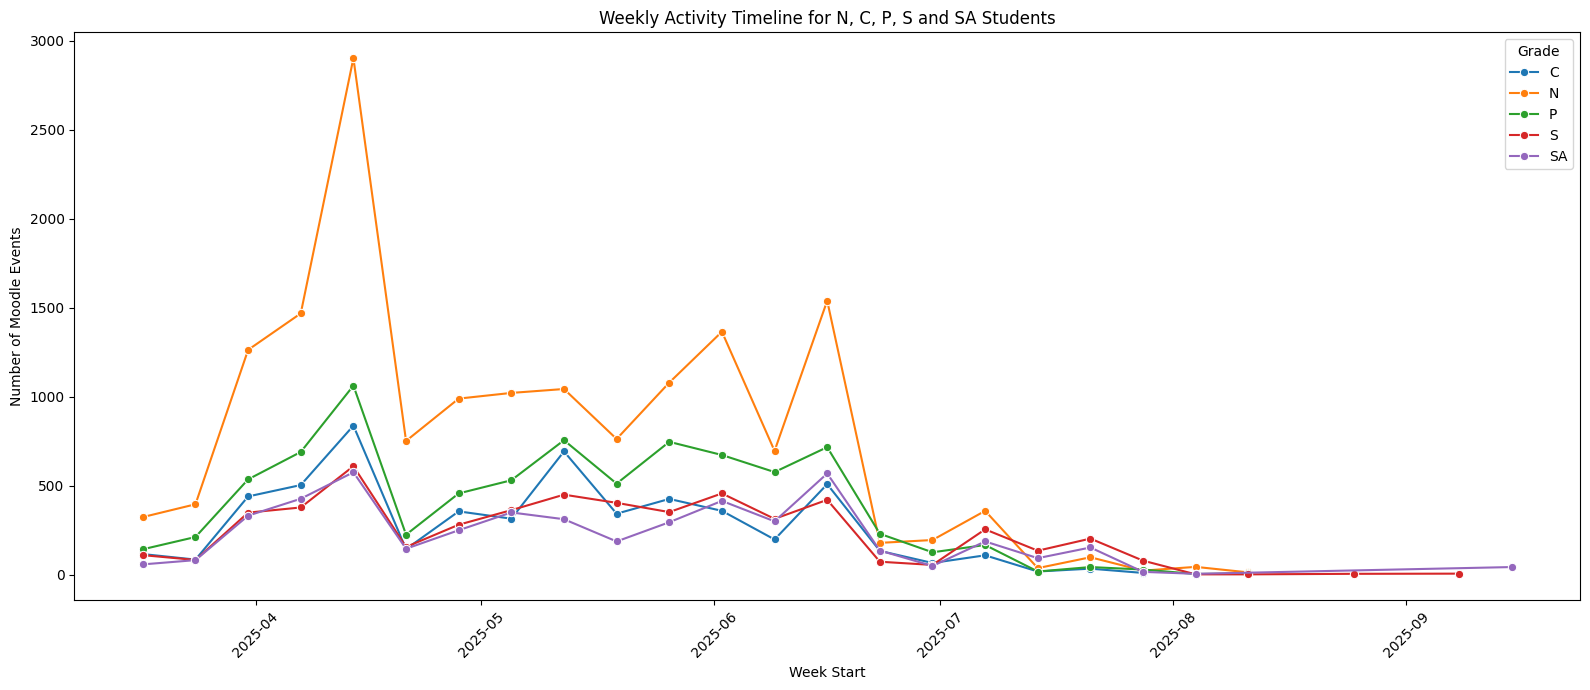

In [42]:
# compare only C, P, S, SA, N
focus_grades = ['N', 'C', 'P', 'S', 'SA']

focus_weekly = weekly_grade_activity[
    weekly_grade_activity['Grade'].isin(focus_grades)
]

plt.figure(figsize=(16, 7))

sns.lineplot(
    data=focus_weekly,
    x='WeekStart',
    y='Event Count',
    hue='Grade',
    marker='o'
)

plt.title('Weekly Activity Timeline for N, C, P, S and SA Students')
plt.xlabel('Week Start')
plt.ylabel('Number of Moodle Events')
plt.xticks(rotation=45)
plt.legend(title='Grade')
plt.tight_layout()
plt.show()

### Diagnostics 2: Does material type influence grade? 

In [43]:
def classify_material(context):
    context = str(context).lower()

    if 'assignment' in context:
        return 'Assignment'

    elif 'quiz' in context:
        return 'Quiz'

    elif 'recorded session' in context:
        return 'Recorded Session'

    elif 'forum' in context:
        return 'Forum'

    elif 'lecture' in context:
        return 'Lecture Material'

    elif 'file' in context:
        return 'File'
    
    elif 'grade' in context or 'report' in context:
        return 'Grade / Report'
    
    elif 'course' in context or 'unit' in context:
        return 'Course / Unit Page'

    else:
        return 'Other'


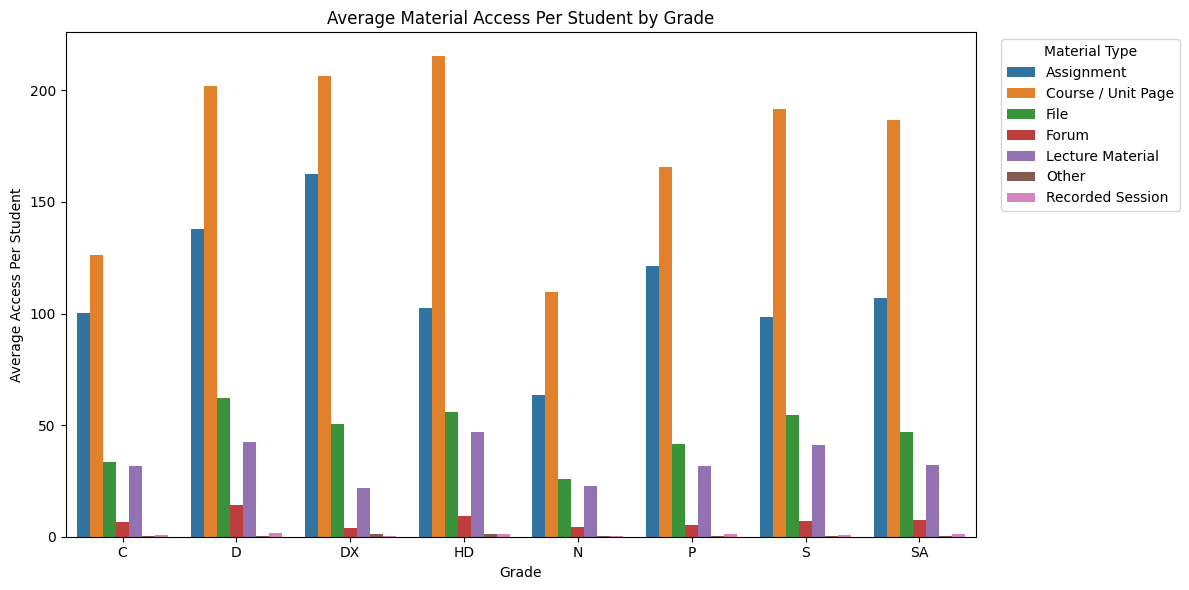

In [45]:
import pandas as pd

import matplotlib.pyplot as plt

logs = pd.read_excel('ICT001 S1 2025 Logs RELEASED V1.0.xlsx')
results = pd.read_excel('ICT001_S1_2025_RESULTS_ALL_MARKS_RELEASED_v1.0[6076970].xlsx', header=2)

results['Person Id'] = (
    results['Person Id']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
    .astype('string')
    .str.strip()
)

results['Person Id'] = (
    results['Person Id']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
)

logs['Material Type'] = logs['Event context'].apply(classify_material)

if 'Person Id' not in logs.columns and 'Username' in logs.columns:
    logs['Person Id'] = (
        logs['Username']
        .astype(str)
        .str.extract(r'(\d+)', expand=False)
        .astype('string')
        .str.strip()
    )

student_material = (
    logs.dropna(subset=['Person Id', 'Material Type'])[['Person Id', 'Material Type']]
    .merge(
        results.dropna(subset=['Person Id', 'Grade'])[['Person Id', 'Grade']],
        on='Person Id',
        how='inner'
    )
)

material_per_student = (
    student_material
    .groupby(['Grade', 'Material Type'])['Person Id']
    .count()
    .reset_index(name='Accesses')
)

grade_counts = (
    results.groupby('Grade')['Person Id']
    .nunique()
    .reset_index(name='Students')
)

material_per_student = material_per_student.merge(
    grade_counts,
    on='Grade',
    how='left'
)

material_per_student['Avg Access Per Student'] = (
    material_per_student['Accesses'] / material_per_student['Students']
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=material_per_student,
    x='Grade',
    y='Avg Access Per Student',
    hue='Material Type'
)

plt.title('Average Material Access Per Student by Grade')
plt.xlabel('Grade')
plt.ylabel('Average Access Per Student')
plt.legend(title='Material Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 

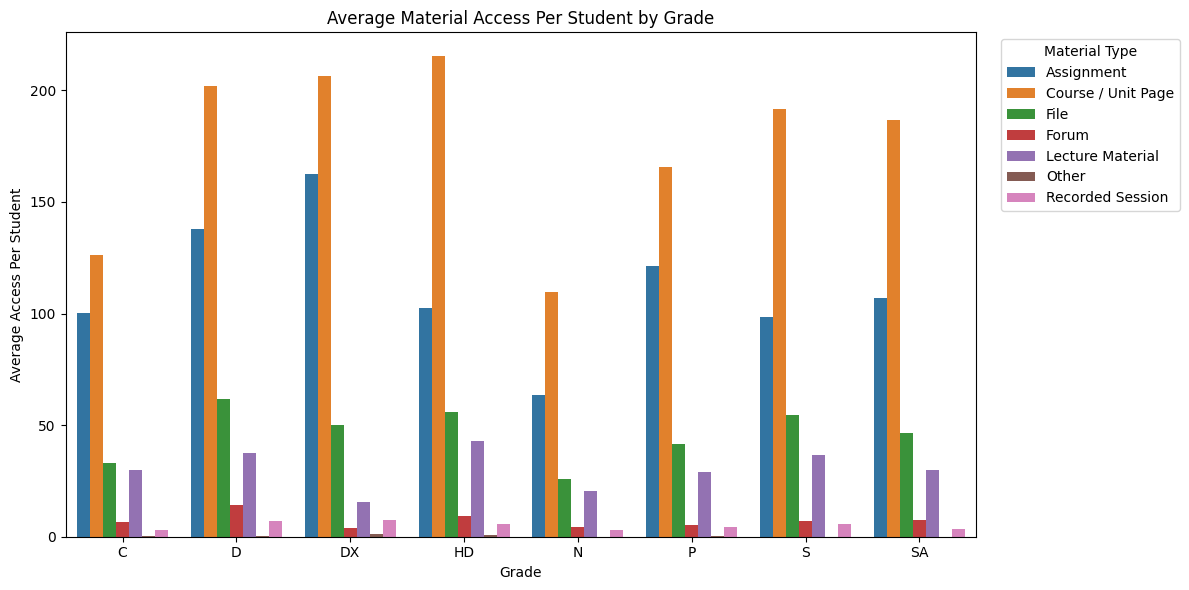

In [47]:
def classify_material(context):
    context = str(context).lower()

    if 'grade' in context or 'report' in context:
        return 'Grade / Report'
    elif 'assignment' in context or 'submission' in context:
        return 'Assignment'
    elif 'quiz' in context:
        return 'Quiz'
    elif 'recorded session' in context or 'recording' in context:
        return 'Recorded Session'
    elif 'forum' in context or 'discussion' in context:
        return 'Forum'
    elif 'lecture' in context or 'slide' in context:
        return 'Lecture Material'
    elif 'file' in context:
        return 'File'
    elif 'course' in context or 'unit' in context:
        return 'Course / Unit Page'
    else:
        return 'Other'


data_log = logs.copy()

data_log['Material Type'] = data_log['Event context'].apply(classify_material)

material_grade = (
    data_log[['Person Id', 'Material Type']]
    .merge(results[['Person Id', 'Grade']], on='Person Id', how='inner')
    .dropna(subset=['Grade', 'Material Type'])
    .groupby(['Grade', 'Material Type'], as_index=False)
    .size()
    .rename(columns={'size': 'Count'})
)

grade_counts = (
    results.groupby('Grade')['Person Id']
    .nunique()
    .reset_index(name='Student Count')
)

material_grade = material_grade.merge(grade_counts, on='Grade', how='left')

material_grade['Avg Access Per Student'] = (
    material_grade['Count'] / material_grade['Student Count']
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=material_grade,
    x='Grade',
    y='Avg Access Per Student',
    hue='Material Type'
)

plt.title('Average Material Access Per Student by Grade')
plt.xlabel('Grade')
plt.ylabel('Average Access Per Student')
plt.legend(title='Material Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Finding 7: Average Material Access Per Student by Grade 

This chart compares the average number of accesses per student for each material type across grade categories. 

### Key observations 
1. Course/Unit Pages are the most accessed resource all grades 
2. Assignment access shows the clear relationship with academic performance 
>> D, HD and even DX have noticeably higher assignment access than N students. 
>> This suggests that assignment related interactions may be a strong indicator of early warning and intervention tool rather than stanalone grade prediction mechanism. 






In [ ]:
# Top Moodle components
logs['Component'].value_counts().head(20)

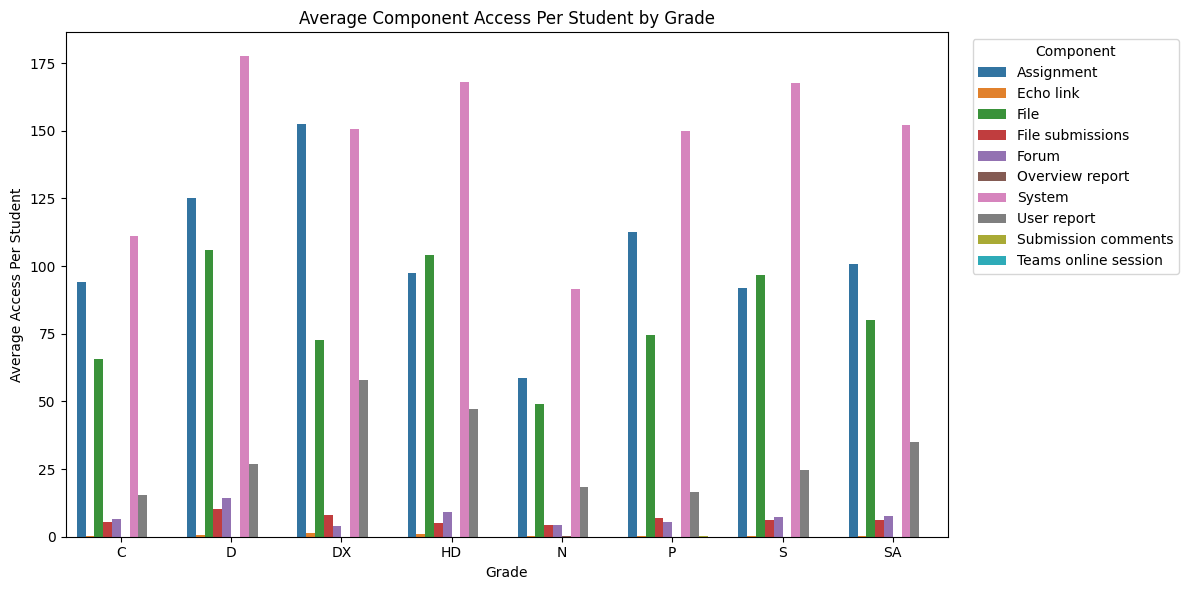

In [48]:
# compare compontent usage by grade category
component_grade = (
    data_log[['Person Id', 'Component']]
    .merge(results[['Person Id', 'Grade']], on='Person Id', how='inner')
    .dropna(subset=['Grade', 'Component'])
    .groupby(['Grade', 'Component'], as_index=False)
    .size()
    .rename(columns={'size': 'Count'})
)
component_grade = component_grade.merge(grade_counts, on='Grade', how='left')
component_grade['Avg Access Per Student'] = component_grade['Count'] / component_grade['Student Count'] 
plt.figure(figsize=(12, 6))
sns.barplot(
    data=component_grade,
    x='Grade',
    y='Avg Access Per Student',
    hue='Component'
)
plt.title('Average Component Access Per Student by Grade')
plt.xlabel('Grade')
plt.ylabel('Average Access Per Student')
plt.legend(title='Component', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [49]:
component_grade = (
    logs[['Person Id', 'Component']]
    .merge(
        results[['Person Id', 'Grade']],
        on='Person Id',
        how='inner'
    )
)

component_grade = (
    component_grade
    .groupby(['Grade', 'Component'])
    .size()
    .reset_index(name='Count')
)

print(component_grade.head(25))

   Grade             Component  Count
0      C            Assignment   1790
1      C             Echo link      5
2      C                  File   1251
3      C      File submissions    106
4      C                 Forum    122
5      C       Overview report      1
6      C                System   2111
7      C           User report    291
8      D            Assignment   2003
9      D             Echo link      8
10     D                  File   1696
11     D      File submissions    161
12     D                 Forum    227
13     D   Submission comments      1
14     D                System   2840
15     D  Teams online session      1
16     D           User report    427
17    DX            Assignment    457
18    DX             Echo link      4
19    DX                  File    218
20    DX      File submissions     24
21    DX                 Forum     12
22    DX                System    452
23    DX           User report    174
24    HD            Assignment    877


In [52]:
active_weeks = (
    grade_logs
    .groupby(['Person Id', 'Grade'])['WeekStart']
    .nunique()
    .reset_index(name='Active Weeks')
)

active_weeks_summary = (
    active_weeks
    .groupby('Grade')['Active Weeks']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

active_weeks_summary

active_weeks_summary

,count,mean,median,min,max
Grade,,,,,
HD,9,17.666667,18.0,13,21
S,14,17.428571,17.0,13,23
D,16,16.687500,17.0,12,20
DX,3,16.666667,16.0,13,21
SA,13,16.384615,18.0,10,19
P,23,15.739130,17.0,6,19
C,19,14.947368,16.0,9,18
N,71,11.535211,13.0,1,18


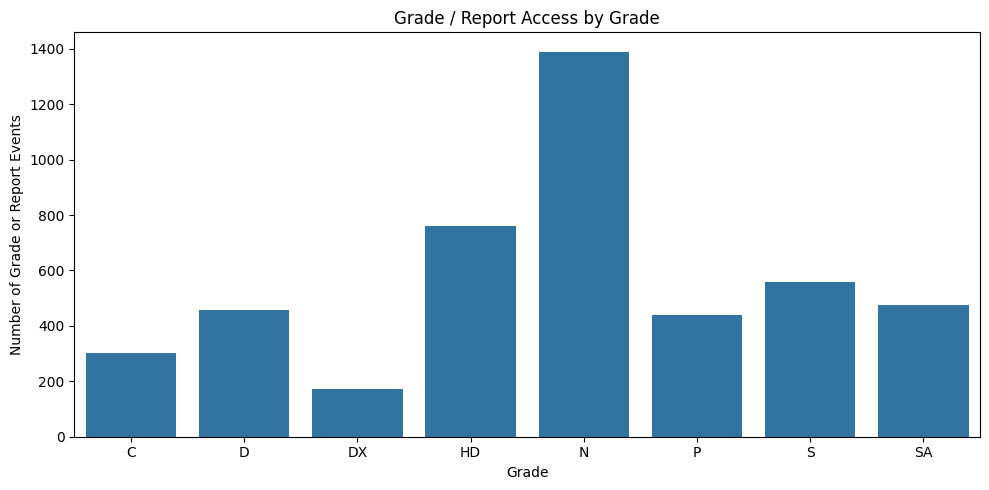

In [53]:
grade_report_logs = grade_logs[
    grade_logs['Event name']
    .astype(str)
    .str.contains('grade|report', case=False, na=False, regex=True)
].copy()

grade_report_summary = (
    grade_report_logs
    .groupby('Grade')
    .size()
    .reset_index(name='Grade Report Events')
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=grade_report_summary,
    x='Grade',
    y='Grade Report Events'
)

plt.title('Grade / Report Access by Grade')
plt.xlabel('Grade')
plt.ylabel('Number of Grade or Report Events')
plt.tight_layout()
plt.show()

In [54]:
s_sa_logs = grade_logs[
    grade_logs['Grade'].isin(['S', 'SA'])
]

top_s_sa_materials = (
    s_sa_logs['Event context']
    .value_counts()
    .head(20)
)

top_s_sa_materials

Event context
Unit: ICT001 Theory of Programming (S1, 2025)                                 5109
File: Lab description (PDF)                                                    905
Assignment: Assignment 1                                                       827
Assignment: Assignment 2                                                       651
File: Lecture Slides (PPT for students)                                        360
File: Lecture Slides (PPT)                                                     228
File: Lecture Notes (PDF)                                                      201
Forum: Announcements (all students)                                            199
Assignment: Assessed Exercise Week 4 (for students enrolled Face-to-Face)      161
Assignment: Assessed Exercise Week 6 (for students enrolled Face-to-Face)      148
Assignment: Assessed Exercise Week 8 (for students enrolled Face-to-Face)      133
Assignment: Assessed Exercise Week 3 (for students enrolled Face-to-Face)

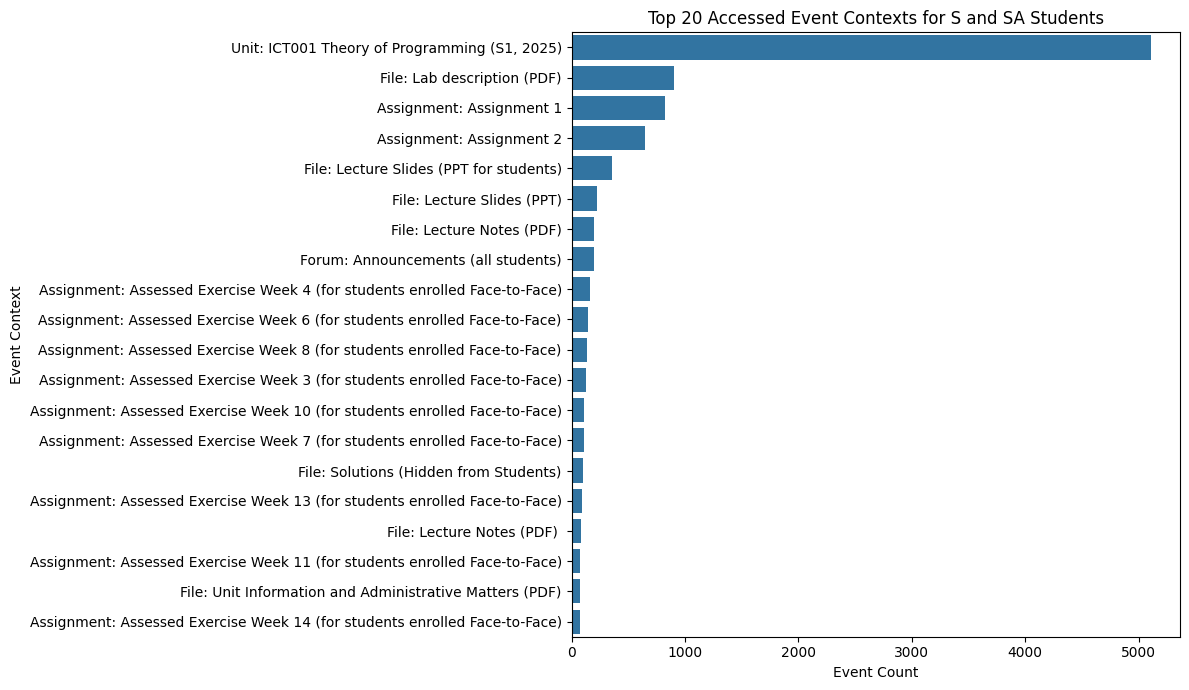

In [55]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_s_sa_materials.values,
    y=top_s_sa_materials.index
)

plt.title('Top 20 Accessed Event Contexts for S and SA Students')
plt.xlabel('Event Count')
plt.ylabel('Event Context')
plt.tight_layout()
plt.show()

In [56]:
c_logs = grade_logs[
    grade_logs['Grade'] == 'C'
]

top_c_materials = (
    c_logs['Event context']
    .value_counts()
    .head(20)
)

top_c_materials

Event context
Unit: ICT001 Theory of Programming (S1, 2025)                                 2396
Assignment: Assignment 1                                                       579
Assignment: Assignment 2                                                       450
File: Lab description (PDF)                                                    389
File: Lecture Slides (PPT for students)                                        173
File: Lecture Slides (PPT)                                                     172
File: Lecture Notes (PDF)                                                      147
Forum: Announcements (all students)                                            122
Assignment: Assessed Exercise Week 4 (for students enrolled Face-to-Face)      117
Assignment: Assessed Exercise Week 6 (for students enrolled Face-to-Face)      116
Assignment: Assessed Exercise Week 10 (for students enrolled Face-to-Face)     103
Assignment: Assessed Exercise Week 3 (for students enrolled Face-to-Face)

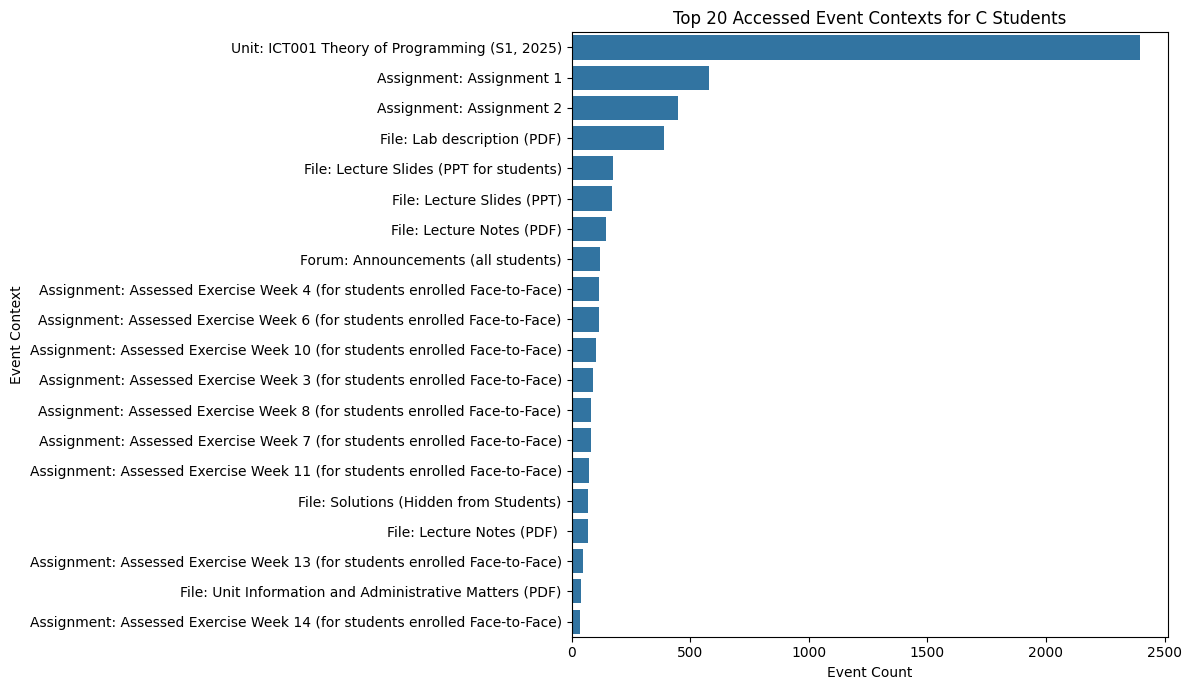

In [57]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_c_materials.values,
    y=top_c_materials.index
)

plt.title('Top 20 Accessed Event Contexts for C Students')
plt.xlabel('Event Count')
plt.ylabel('Event Context')
plt.tight_layout()
plt.show()

## Does early assignment engagement relate to performance? 

In [65]:
# check the time student accessed assignment materials and group by grade category - normalize by student count in each grade category

# Choose correct log dataframe

if 'logs' in globals():
    log_df = logs.copy()

elif 'data_log' in globals():
    log_df = data_log.copy()

else:
    raise NameError("No log dataframe found. Please load logs or data_log first.")

# Choose correct results datafram
if 'results' in globals():
    results_df = results.copy()

elif 'results_data' in globals():
    results_df = globals()['results_data'].copy()

else:
    raise NameError("No results dataframe found. Please load results or results_data first.")

# Clean Person Id
log_df['Person Id'] = (
    log_df['Person Id']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
)

results_df['Person Id'] = (
    results_df['Person Id']
    .astype(str)
    .str.extract(r'(\d+)', expand=False)
)

# Convert Time
log_df['Time'] = pd.to_datetime(
    logs['Time'],
    format='%d/%m/%y, %H:%M:%S',
    errors='coerce'

)

log_df = log_df.dropna(subset=['Time', 'Person Id'])

# Merge grade and mark into logs
grade_logs = log_df.merge(
    results_df[['Person Id', 'Grade', 'Mark']],
    on='Person Id',
    how='inner'
)

grade_logs['Mark'] = pd.to_numeric(grade_logs['Mark'], errors='coerce')

# Create week
grade_logs['WeekStart'] = (
    grade_logs['Time']
    .dt.to_period('W')
    .dt.start_time

)

In [64]:
logs['Time'].head(10)

0    13/11/25, 09:55:28
1    20/09/25, 19:30:02
2    20/09/25, 19:29:35
3    20/09/25, 19:29:08
4    20/09/25, 19:29:04
5    20/09/25, 19:28:42
6    20/09/25, 19:28:18
7    20/09/25, 19:28:14
8    20/09/25, 19:27:50
9    20/09/25, 19:27:16
Name: Time, dtype: object

In [67]:
# assignment access timing 
assignment_logs = grade_logs[
    (grade_logs['Component'].astype(str).str.contains('Assignment', case=False, na=False)) |
    (grade_logs['Event context'].astype(str).str.contains('assignment', case=False, na=False))
].copy()

first_assignment_access = (
    assignment_logs
    .groupby(['Person Id', 'Grade', 'Mark'])['Time']
    .min()
    .reset_index(name='First Assignment Access')
)

term_start = grade_logs['Time'].min()

first_assignment_access['Days From Term Start'] = (
    first_assignment_access['First Assignment Access'] - term_start
).dt.days

first_assignment_access.head()

,Person Id,Grade,Mark,First Assignment Access,Days From Term Start
0,15925001,P,52.0,2025-04-14 12:32:13,24
1,15925002,N,38.0,2025-03-21 13:30:56,0
2,15925003,N,2.0,2025-04-07 17:48:26,17
3,15925004,S,46.0,2025-03-21 10:02:20,0
4,15925005,S,45.0,2025-03-21 13:55:06,0


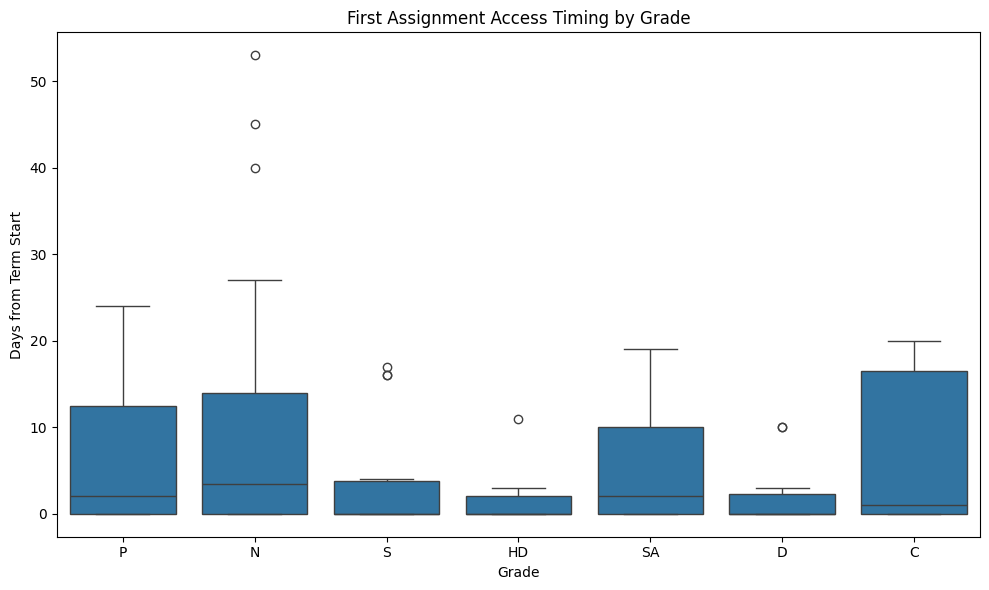

In [68]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=first_assignment_access,
    x='Grade',
    y='Days From Term Start'
)

plt.title('First Assignment Access Timing by Grade')
plt.xlabel('Grade')
plt.ylabel('Days from Term Start')
plt.tight_layout()
plt.show()

### Observation: 
High-performaning students tend to access earlier
N students show the largest delay variation 
C students have unusual behavior - many accessed early but spread very large, some waited nearly 20 days. 


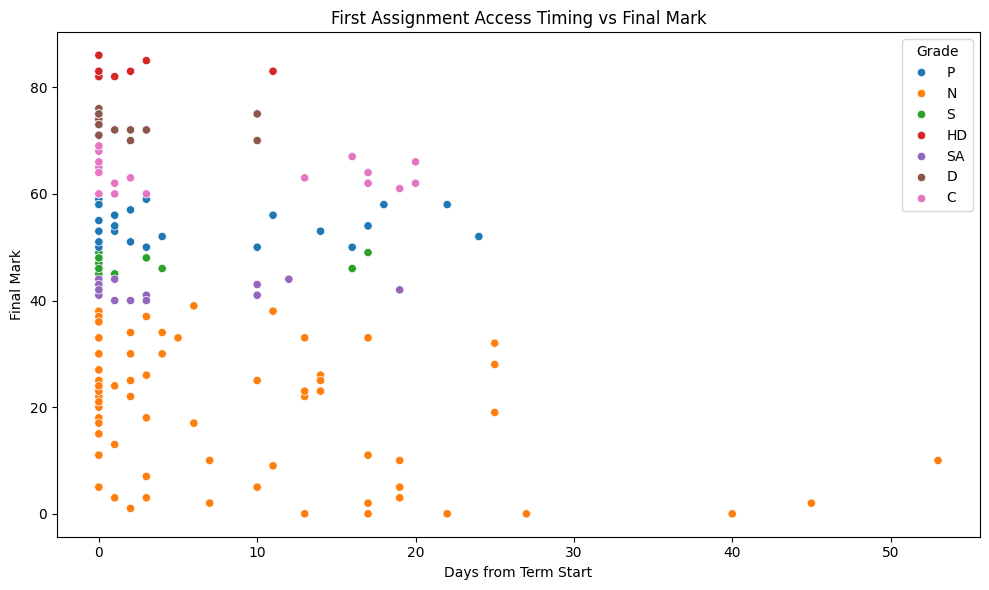

In [69]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=first_assignment_access,
    x='Days From Term Start',
    y='Mark',
    hue='Grade'
)

plt.title('First Assignment Access Timing vs Final Mark')
plt.xlabel('Days from Term Start')
plt.ylabel('Final Mark')
plt.tight_layout()
plt.show()

In [70]:
first_assignment_access[['Days From Term Start', 'Mark']].corr()

,Days From Term Start,Mark
Days From Term Start,1.00000,-0.32413
Mark,-0.32413,1.00000


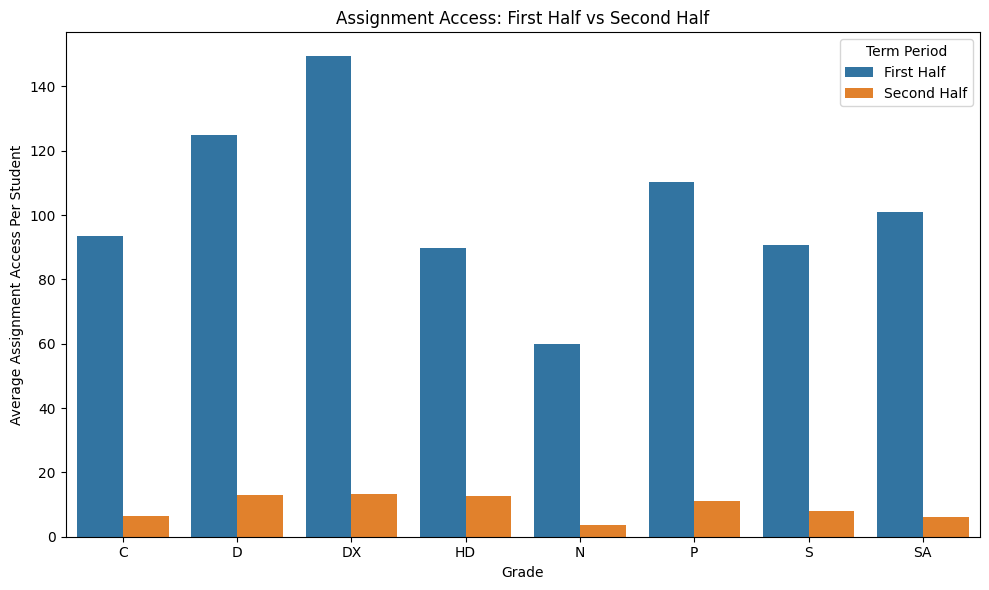

In [71]:
midpoint = term_start + (grade_logs['Time'].max() - term_start) / 2

assignment_logs['Term Period'] = np.where(
    assignment_logs['Time'] < midpoint,
    'First Half',
    'Second Half'
)

assignment_period = (
    assignment_logs
    .groupby(['Grade', 'Term Period'])['Person Id']
    .count()
    .reset_index(name='Assignment Access Count')
)

grade_counts = (
    results_df
    .groupby('Grade')['Person Id']
    .nunique()
    .reset_index(name='Students')
)

assignment_period = assignment_period.merge(grade_counts, on='Grade', how='left')

assignment_period['Avg Assignment Access Per Student'] = (
    assignment_period['Assignment Access Count'] / assignment_period['Students']
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=assignment_period,
    x='Grade',
    y='Avg Assignment Access Per Student',
    hue='Term Period'
)

plt.title('Assignment Access: First Half vs Second Half')
plt.xlabel('Grade')
plt.ylabel('Average Assignment Access Per Student')
plt.tight_layout()
plt.show()

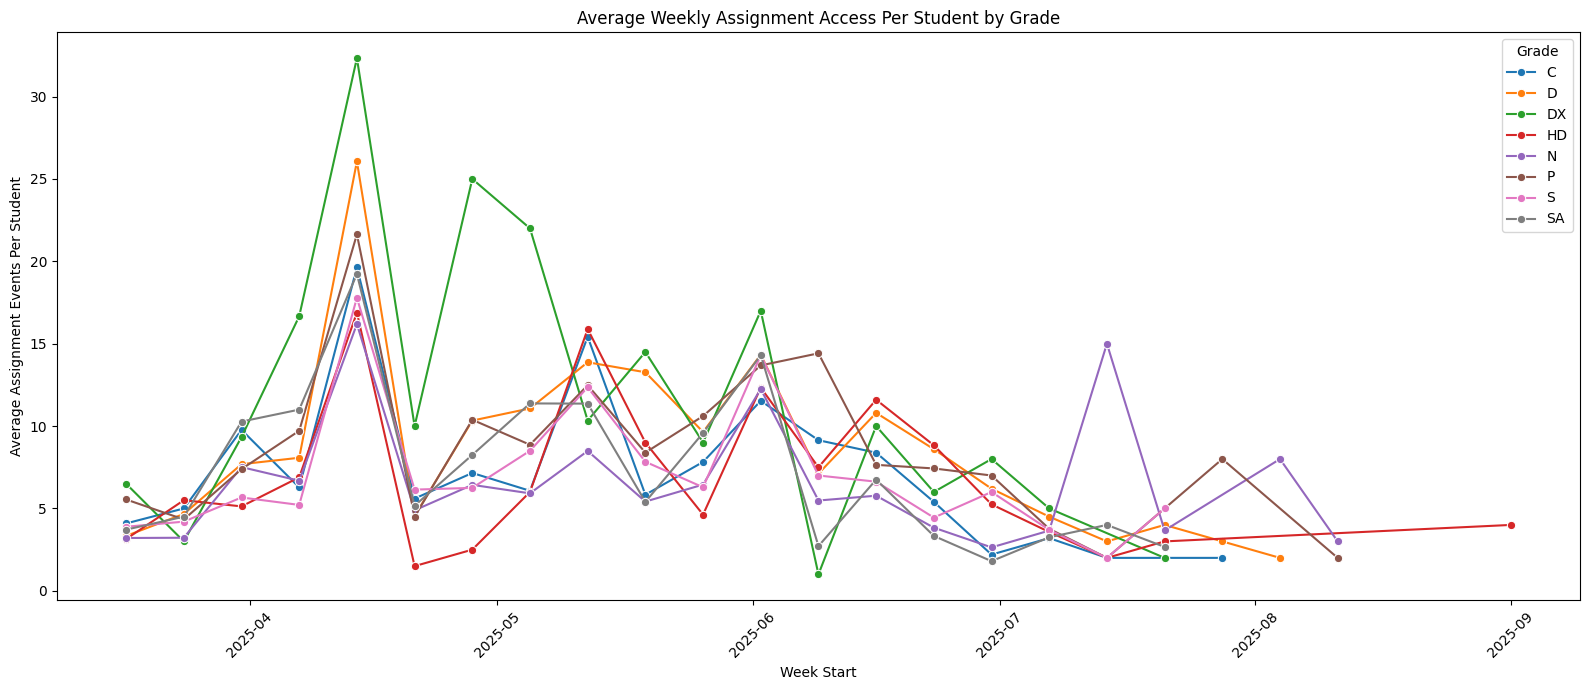

In [72]:
weekly_assignment = (
    assignment_logs
    .groupby(['WeekStart', 'Grade', 'Person Id'])
    .size()
    .reset_index(name='Events')
)

weekly_assignment_avg = (
    weekly_assignment
    .groupby(['WeekStart', 'Grade'])['Events']
    .mean()
    .reset_index(name='Avg Assignment Events Per Student')
)

plt.figure(figsize=(16, 7))

sns.lineplot(
    data=weekly_assignment_avg,
    x='WeekStart',
    y='Avg Assignment Events Per Student',
    hue='Grade',
    marker='o'
)

plt.title('Average Weekly Assignment Access Per Student by Grade')
plt.xlabel('Week Start')
plt.ylabel('Average Assignment Events Per Student')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

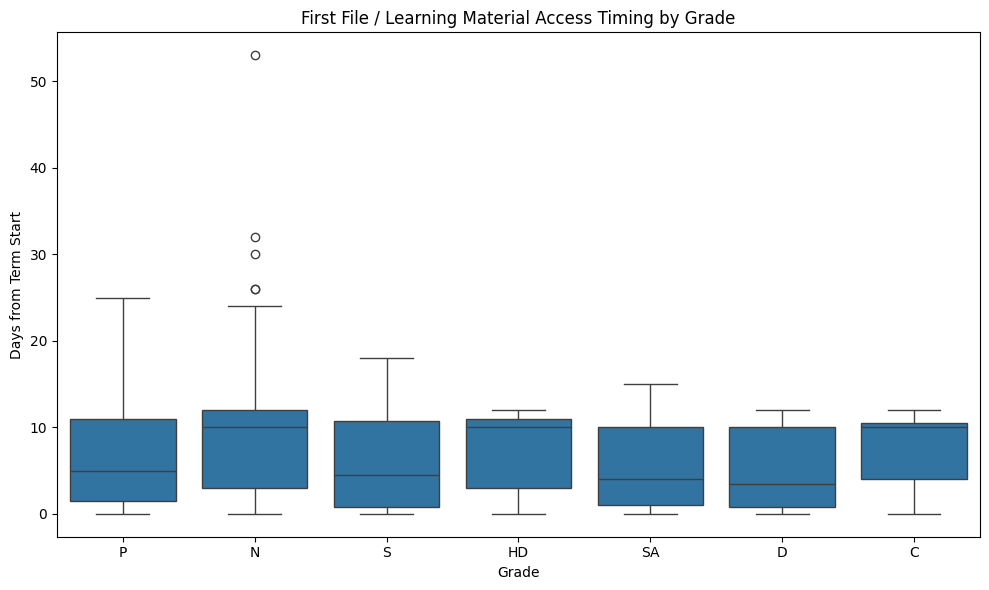

In [74]:
file_logs = grade_logs[
    (grade_logs['Component'].astype(str).str.contains('File', case=False, na=False)) |
    (grade_logs['Event context'].astype(str).str.contains('file|lecture|slide', case=False, na=False))
].copy()

first_file_access = (
    file_logs
    .groupby(['Person Id', 'Grade', 'Mark'])['Time']
    .min()
    .reset_index(name='First File Access')
)

first_file_access['Days From Term Start'] = (
    first_file_access['First File Access'] - term_start
).dt.days

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=first_file_access,
    x='Grade',
    y='Days From Term Start'
)

plt.title('First File / Learning Material Access Timing by Grade')
plt.xlabel('Grade')
plt.ylabel('Days from Term Start')
plt.tight_layout()
plt.show()

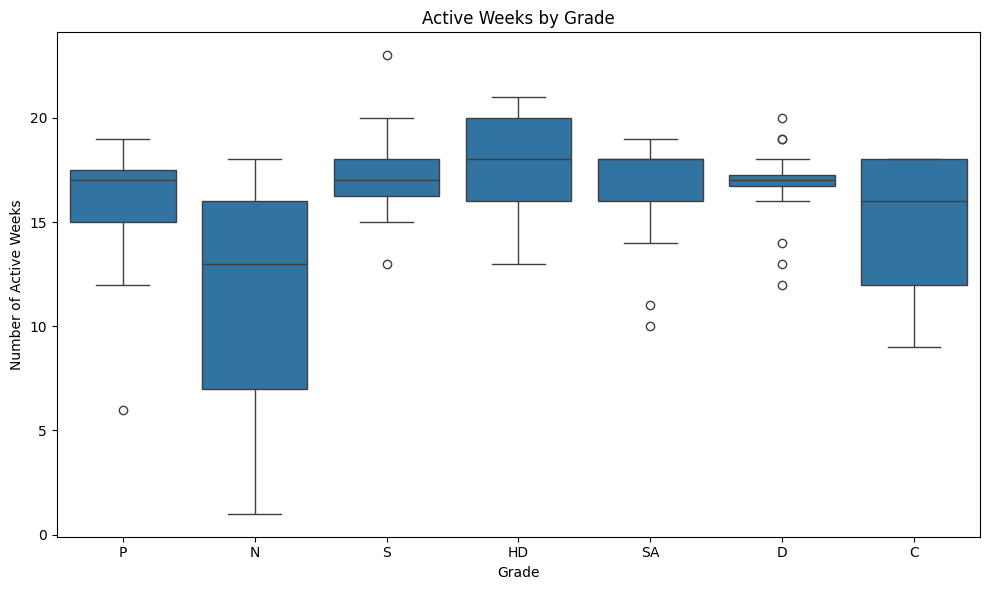

In [75]:
student_active_weeks = (
    grade_logs
    .groupby(['Person Id', 'Grade', 'Mark'])['WeekStart']
    .nunique()
    .reset_index(name='Active Weeks')
)

student_active_weeks.groupby('Grade')['Active Weeks'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=student_active_weeks,
    x='Grade',
    y='Active Weeks'
)

plt.title('Active Weeks by Grade')
plt.xlabel('Grade')
plt.ylabel('Number of Active Weeks')
plt.tight_layout()
plt.show()

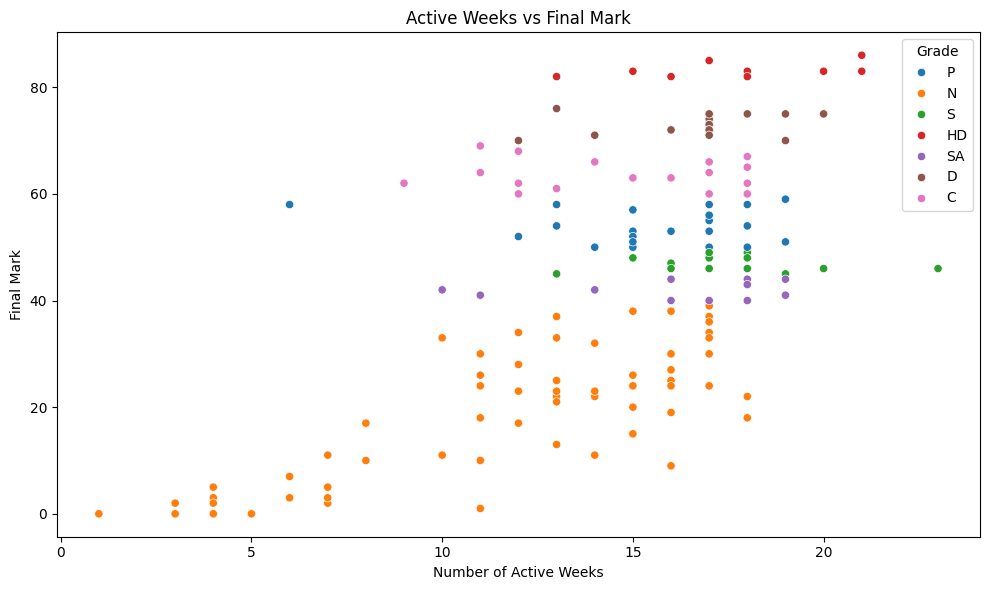

In [76]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=student_active_weeks,
    x='Active Weeks',
    y='Mark',
    hue='Grade'
)

plt.title('Active Weeks vs Final Mark')
plt.xlabel('Number of Active Weeks')
plt.ylabel('Final Mark')
plt.tight_layout()
plt.show()

In [99]:
student_active_weeks[['Active Weeks', 'Mark']].corr()

,Active Weeks,Mark
Active Weeks,1.000000,0.647034
Mark,0.647034,1.000000


In [78]:
results_df.columns.tolist()

['Person Id',
 'Surname',
 'Mark',
 'Grade',
 'Ass Ex 1',
 'Ass Ex 2',
 'Ass Ex 3',
 'Ass Ex 4',
 'Ass Ex 5',
 'Ass Ex 6',
 'Ass Ex 7',
 'Ass Ex 8',
 'Ass Ex 9',
 'Ass Ex 10',
 'Weekly Lab Quizzes / 100',
 'Assignment 1 / 100',
 'Delay (days)',
 'Ass 1 with Penalty /100',
 'Ass 2 /100',
 'Delay (days).1',
 'Ass 2 with Penalty /100',
 'Exam/ 100',
 'Total/ 100',
 'Rounded Total/ 100',
 'Cal G']

In [79]:
delay_cols = [
    col for col in results_df.columns
    if 'Delay' in str(col) and 'days' in str(col)
]

delay_cols

['Delay (days)', 'Delay (days).1']

In [80]:
delay_df = results_df[['Person Id', 'Grade', 'Mark'] + delay_cols].copy()

for col in delay_cols:
    delay_df[col] = pd.to_numeric(delay_df[col], errors='coerce')

delay_df['Total Delay Days'] = delay_df[delay_cols].sum(axis=1, skipna=True)

delay_df.groupby('Grade')['Total Delay Days'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
Grade,,,,,
C,19,0.0,0.0,0.0,0.0
D,16,0.0,0.0,0.0,0.0
DX,3,0.0,0.0,0.0,0.0
HD,9,0.0,0.0,0.0,0.0
N,73,0.0,0.0,0.0,0.0
P,23,0.0,0.0,0.0,0.0
S,14,0.0,0.0,0.0,0.0
SA,13,0.0,0.0,0.0,0.0


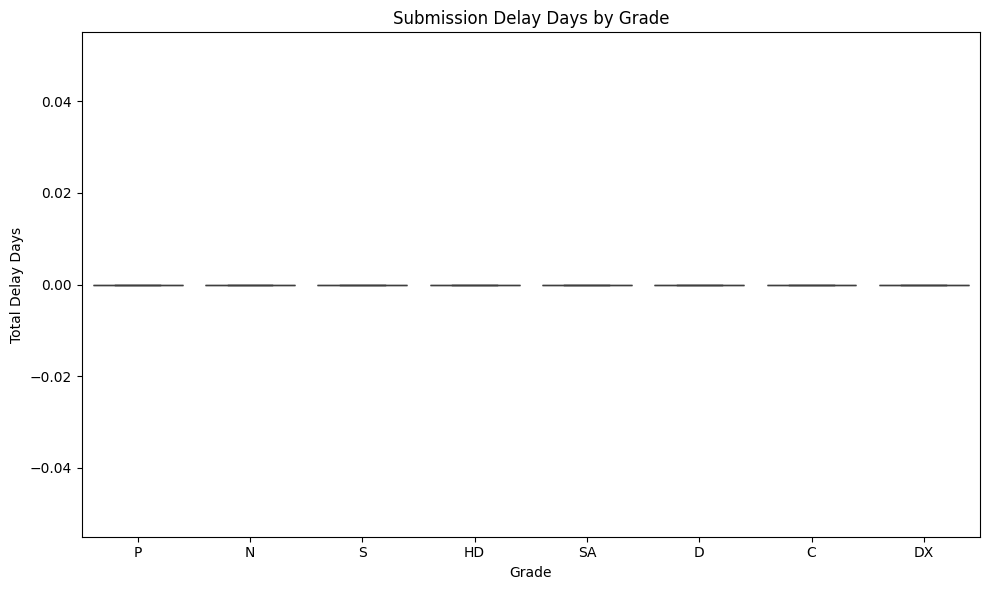

In [81]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=delay_df,
    x='Grade',
    y='Total Delay Days'
)

plt.title('Submission Delay Days by Grade')
plt.xlabel('Grade')
plt.ylabel('Total Delay Days')
plt.tight_layout()
plt.show()

In [82]:
delay_df[['Total Delay Days', 'Mark']].corr()

,Total Delay Days,Mark
Total Delay Days,NaN,NaN
Mark,NaN,1.0


In [83]:
student_features = (
    results_df[['Person Id', 'Grade', 'Mark']]
    .merge(
        student_active_weeks[['Person Id', 'Active Weeks']],
        on='Person Id',
        how='left'
    )
    .merge(
        first_assignment_access[['Person Id', 'Days From Term Start']]
        .rename(columns={'Days From Term Start': 'Days To First Assignment Access'}),
        on='Person Id',
        how='left'
    )
    .merge(
        first_file_access[['Person Id', 'Days From Term Start']]
        .rename(columns={'Days From Term Start': 'Days To First File Access'}),
        on='Person Id',
        how='left'
    )
    .merge(
        delay_df[['Person Id', 'Total Delay Days']],
        on='Person Id',
        how='left'
    )
)

student_features.head()

,Person Id,Grade,Mark,Active Weeks,Days To First Assignment Access,Days To First File Access,Total Delay Days
0,15925001,P,52.0,12.0,24.0,25.0,0.0
1,15925002,N,38.0,15.0,0.0,10.0,0.0
2,15925003,N,2.0,7.0,17.0,10.0,0.0
3,15925004,S,46.0,23.0,0.0,0.0,0.0
4,15925005,S,45.0,13.0,0.0,10.0,0.0


In [84]:
student_features[['Mark', 
                  'Active Weeks', 
                  'Days To First Assignment Access',
                  'Days To First File Access',
                  'Total Delay Days']].corr()

,Mark,Active Weeks,Days To First Assignment Access,Days To First File Access,Total Delay Days
Mark,1.000000,0.647034,-0.324130,-0.236554,NaN
Active Weeks,0.647034,1.000000,-0.490777,-0.328560,NaN
Days To First Assignment Access,-0.324130,-0.490777,1.000000,0.575138,NaN
Days To First File Access,-0.236554,-0.328560,0.575138,1.000000,NaN
Total Delay Days,NaN,NaN,NaN,NaN,NaN


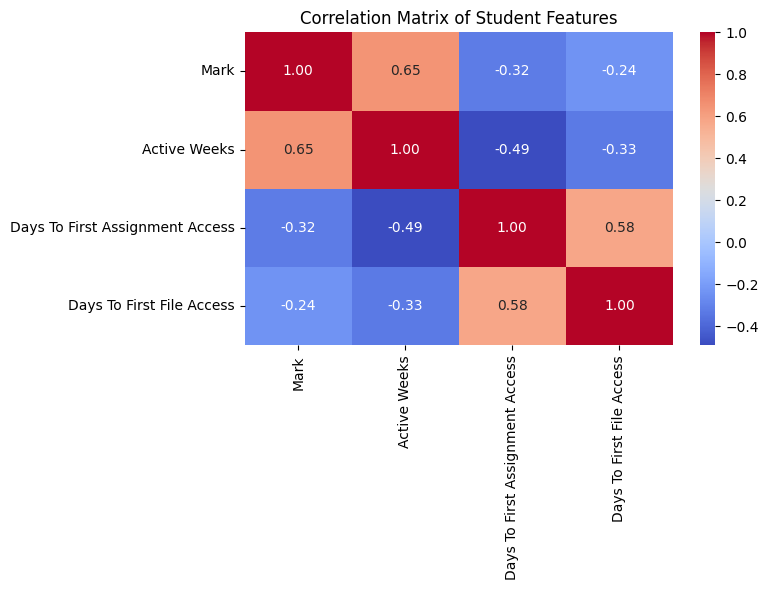

In [88]:
# plot the correlation matrix, exclude total delay days
corr_matrix = student_features[[
    'Mark',
    'Active Weeks',
    'Days To First Assignment Access',
    'Days To First File Access'
]].corr()   
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Student Features')
plt.tight_layout()
plt.show()  


In [89]:
quiz_col = 'Weekly Lab Quizzes / 100'

results[['Grade', quiz_col]].groupby('Grade').mean()

,Weekly Lab Quizzes / 100
Grade,
C,71.442105
D,88.012500
DX,57.500000
HD,91.388889
N,28.952055
P,67.386957
S,66.135714
SA,67.269231


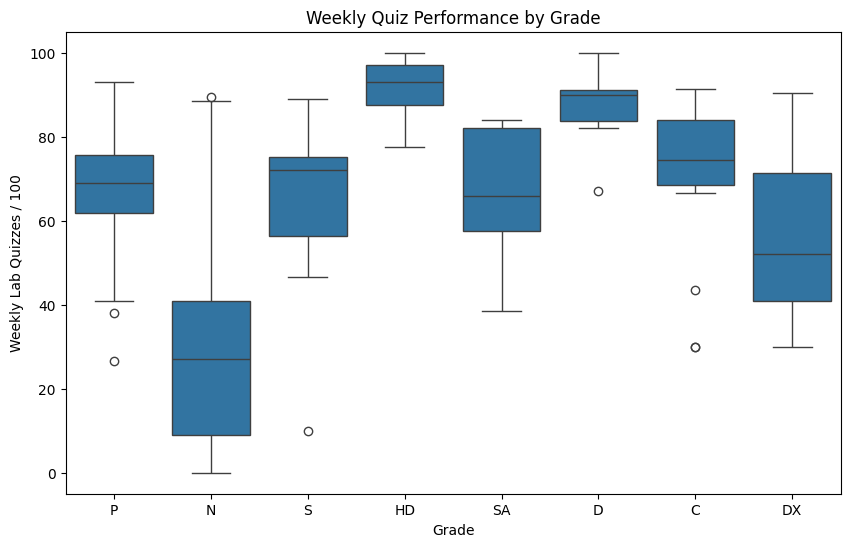

In [90]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=results,
    x='Grade',
    y=quiz_col
)

plt.title('Weekly Quiz Performance by Grade')
plt.show()

In [91]:
results[['Mark', quiz_col]].corr()

,Mark,Weekly Lab Quizzes / 100
Mark,1.00000,0.83374
Weekly Lab Quizzes / 100,0.83374,1.00000


In [95]:
# assignment 1 vs final mark correlation
assignment_col = 'Assignment 1 / 100'
tmp = results[['Mark', assignment_col]].copy()
tmp['Mark'] = pd.to_numeric(tmp['Mark'], errors='coerce')
tmp[assignment_col] = pd.to_numeric(tmp[assignment_col], errors='coerce')

tmp.dropna(subset=['Mark', assignment_col]).corr()


,Mark,Assignment 1 / 100
Mark,1.000000,0.612789
Assignment 1 / 100,0.612789,1.000000


In [98]:
# assignment 2 vs final mark correlation
assignment_col = 'Assignment 2 / 100'
# resolve actual Assignment 2 column name safely
candidate_cols = [assignment_col, 'Ass 2 /100', 'Ass 2/100', 'Ass 2 with Penalty /100']
assignment_col = next((c for c in candidate_cols if c in results.columns), None)

if assignment_col is None:
    raise KeyError(f"None of the expected Assignment 2 columns found. Available columns: {results.columns.tolist()}")

tmp = results[['Mark', assignment_col]].copy()
tmp['Mark'] = pd.to_numeric(tmp['Mark'], errors='coerce')
tmp[assignment_col] = pd.to_numeric(tmp[assignment_col], errors='coerce')   
tmp.dropna(subset=['Mark', assignment_col]).corr()  

,Mark,Ass 2 /100
Mark,1.000000,0.691885
Ass 2 /100,0.691885,1.000000


In [ ]:
# plot all correlations in heatmap 
